In [1]:
# Libraries
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from scipy import stats

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             precision_score, recall_score, f1_score, roc_auc_score, 
                             roc_curve, precision_recall_curve, mean_squared_error, 
                             mean_absolute_error, r2_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Binomial
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
random.seed(67)

# Start of Linear Probability Model

In [3]:
# Load dataset and check size
data = fetch_openml(data_id=43436, as_frame=True)
df = data.frame
print(f"Data loaded successfully, Dataset Size: {len(df)} rows")

Data loaded successfully, Dataset Size: 32561 rows


In [4]:
df  # check dataset

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,=50K


In [5]:
df['education'].unique()  # Reference for categorical beta coefficient

<StringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str

In [6]:
df['workclass'].unique()  # Reference for categorical beta coefficient

<StringArray>
[               nan,          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

In [7]:
df['occupation'].unique()  # Reference for categorical beta coefficient

<StringArray>
[                nan,   'Exec-managerial', 'Machine-op-inspct',
    'Prof-specialty',     'Other-service',      'Adm-clerical',
      'Craft-repair',  'Transport-moving', 'Handlers-cleaners',
             'Sales',   'Farming-fishing',      'Tech-support',
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

In [8]:
# check for null values
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [9]:
df_clean = df.dropna()  # Dropped null values to ensure safety for the LPM model
df_clean

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,=50K


In [10]:
# check if there are any more null values (if all NaN was dropped)
df_clean.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [11]:
df_clean['education'].unique()  # Reference for categorical beta coefficient

<StringArray>
[     'HS-grad',      '7th-8th', 'Some-college',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',    'Assoc-voc',      '1st-4th',      '5th-6th',
   'Assoc-acdm',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str

In [12]:
df_clean['workclass'].unique()  # Reference for categorical beta coefficient (noticed data loss)

<StringArray>
[         'Private',        'State-gov',      'Federal-gov',
 'Self-emp-not-inc',     'Self-emp-inc',        'Local-gov',
      'Without-pay']
Length: 7, dtype: str

In [13]:
df_clean['occupation'].unique()  # Reference for categorical beta coefficient

<StringArray>
[  'Exec-managerial', 'Machine-op-inspct',    'Prof-specialty',
     'Other-service',      'Adm-clerical',  'Transport-moving',
             'Sales',      'Craft-repair',   'Farming-fishing',
      'Tech-support',   'Protective-serv', 'Handlers-cleaners',
      'Armed-Forces',   'Priv-house-serv']
Length: 14, dtype: str

In [14]:
# check data types per column
df_clean.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [15]:
# check number of values for target (and for masking)
print(df_clean['income'].value_counts())
print("'=50K' is '<=50K' while '50K' is '>50k'")

income
=50K    22654
50K      7508
Name: count, dtype: int64
'=50K' is '<=50K' while '50K' is '>50k'


In [16]:
# number matches with previous cell
df_clean["income_binary"] = (df_clean["income"] == "50K").astype(int)
df_clean["income_binary"].value_counts()

income_binary
0    22654
1     7508
Name: count, dtype: int64

In [17]:
# create dummies while seperating categorical and numerical columns
categorical_cols = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]
numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
df_categ = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_categ

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,income_binary,workclass_Local-gov,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_TrinadadTobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,132870,9,0,4356,18,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,50K,1,False,True,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False


In [18]:
# summary statistic (noticed some potential outliers assuming normality)
df_clean.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238,0.248922
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984,0.432396
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


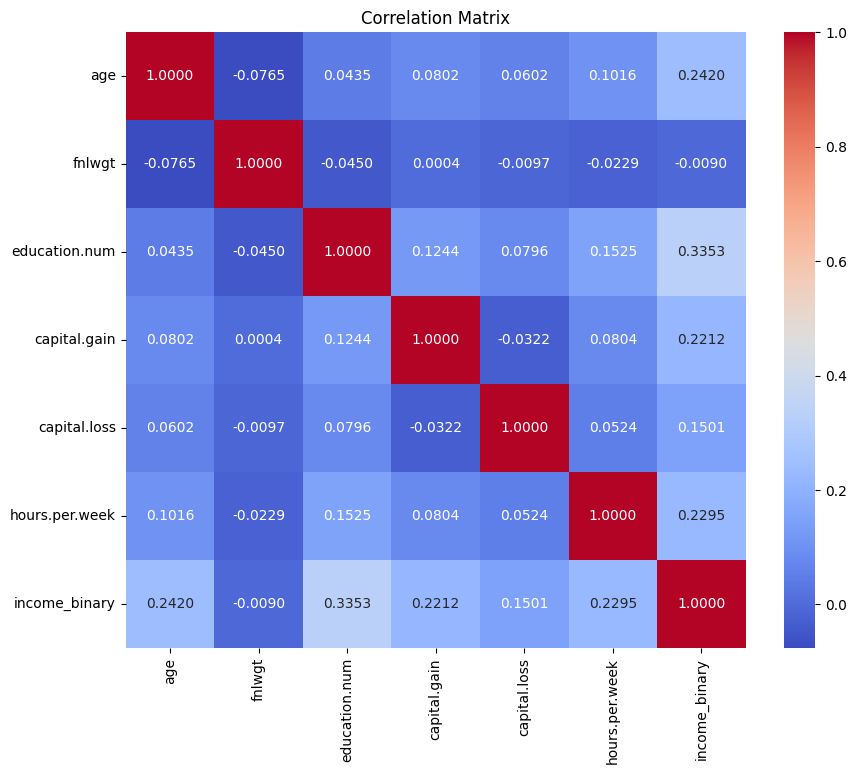

In [19]:
# check if other variables have a high correlation with each other
numeric_df = df_clean.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

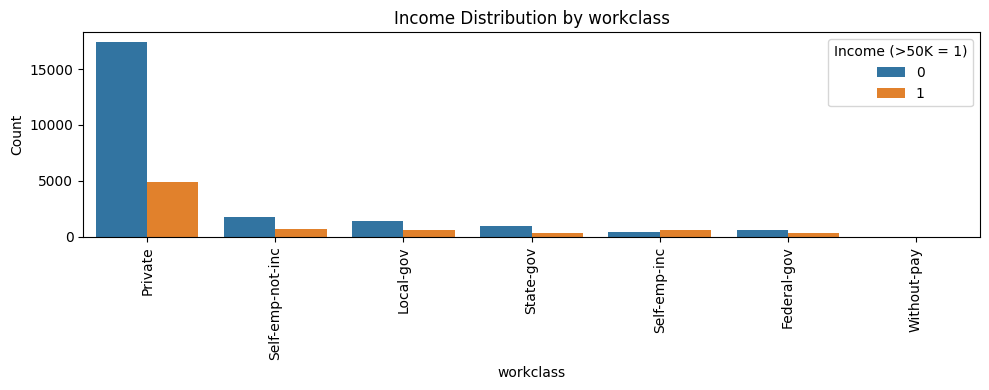

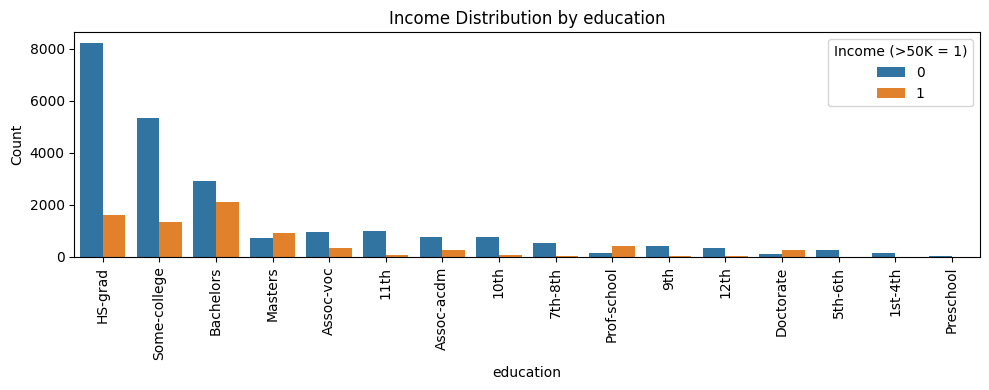

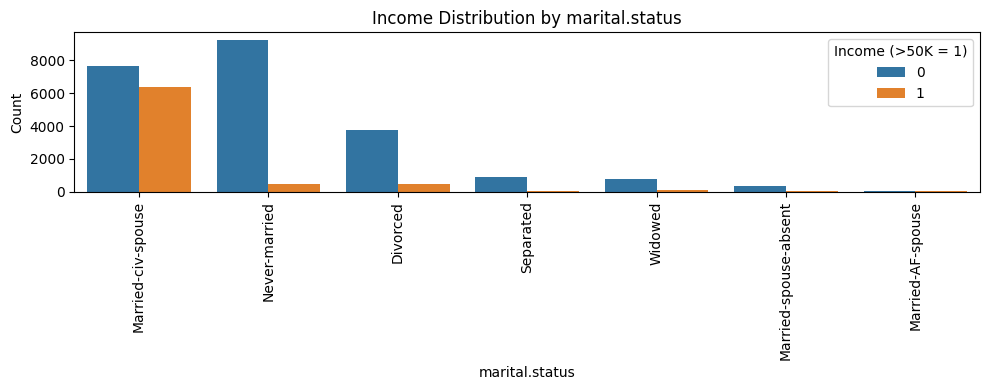

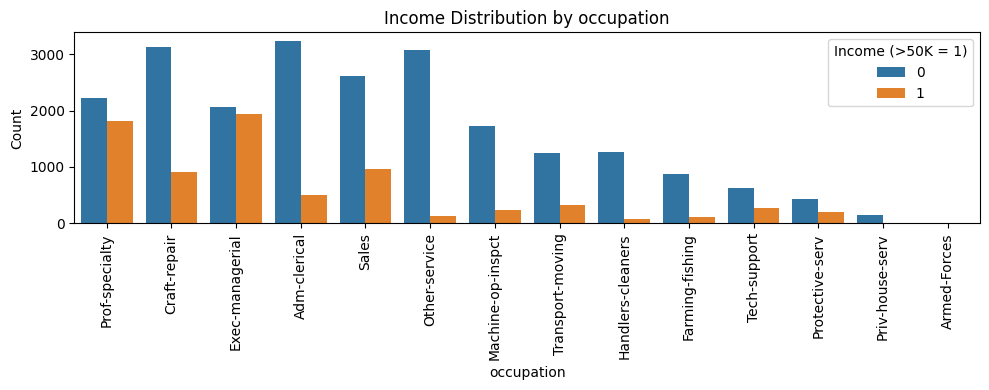

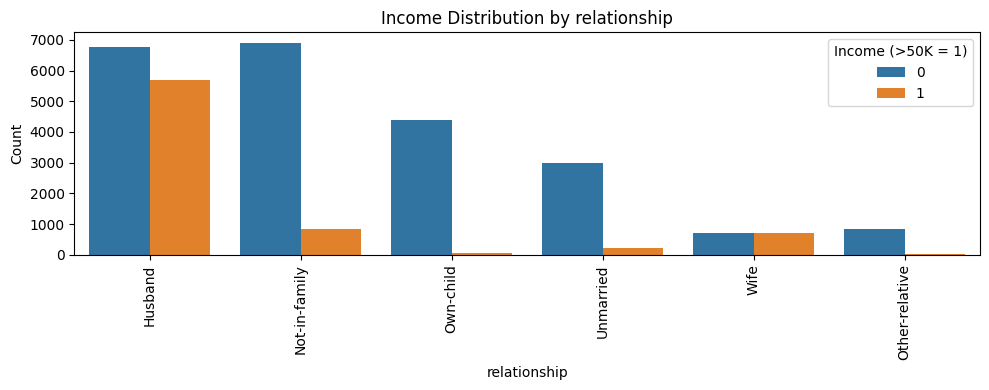

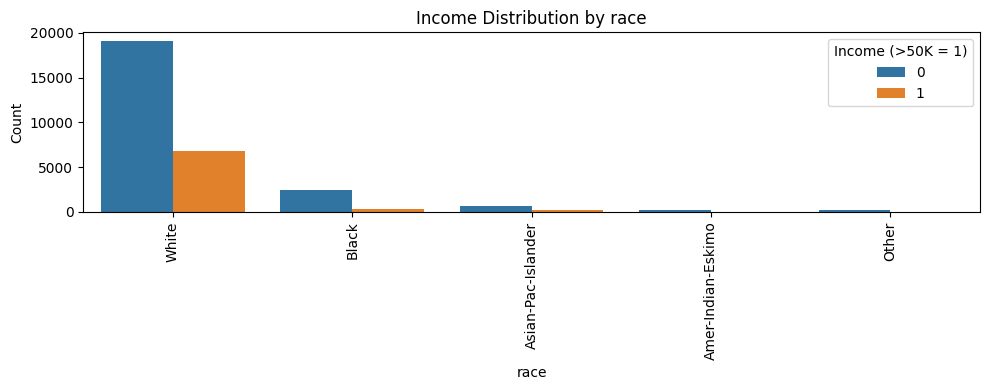

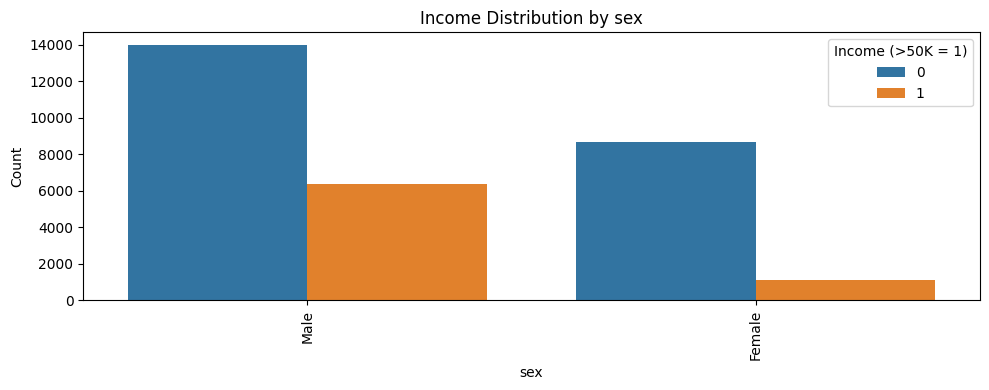

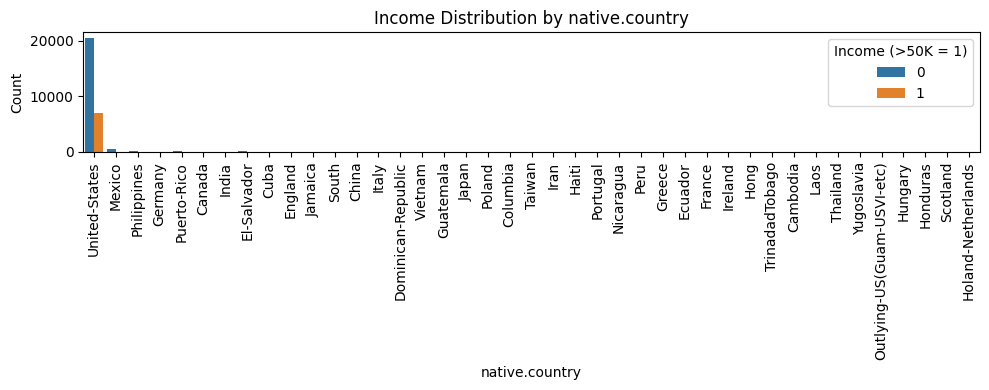

In [20]:
# plot categorical columns
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, hue='income_binary', data=df_clean, order=df_clean[col].value_counts().index)
    plt.title(f"Income Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Income (>50K = 1)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

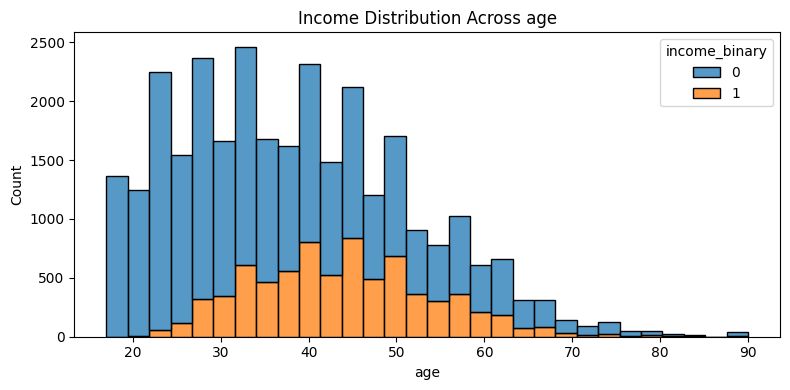

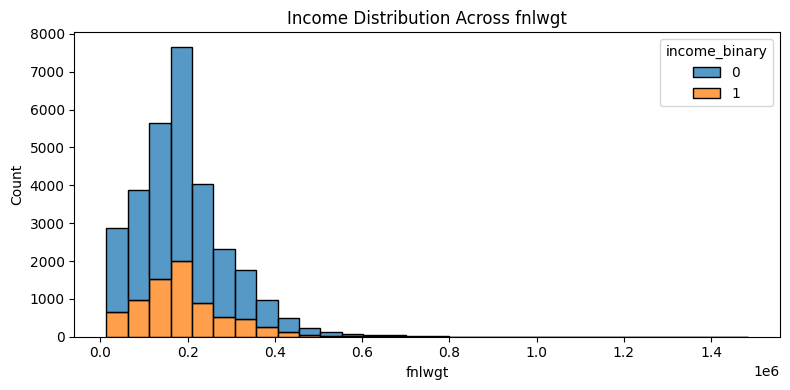

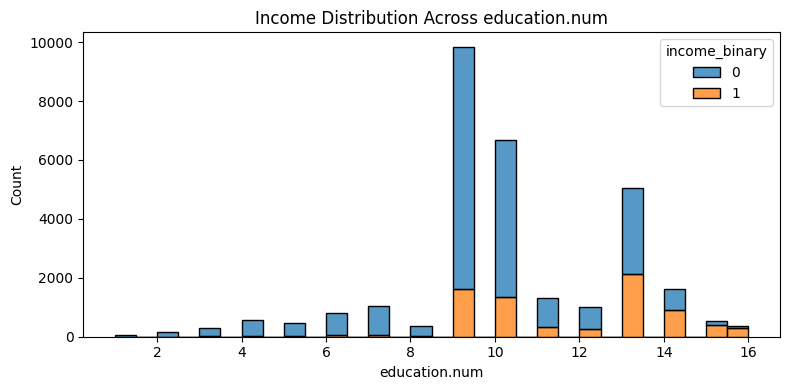

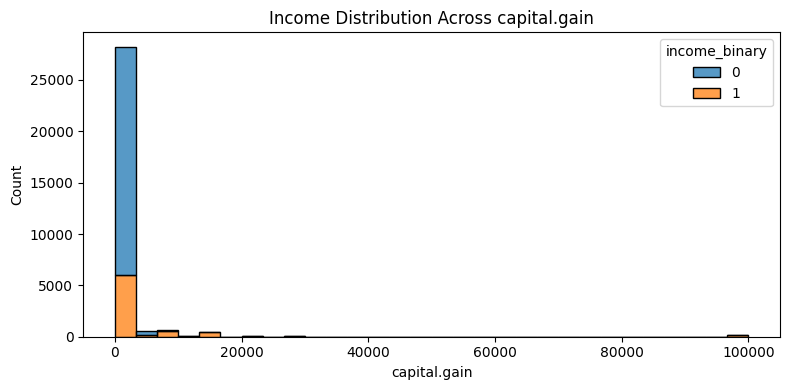

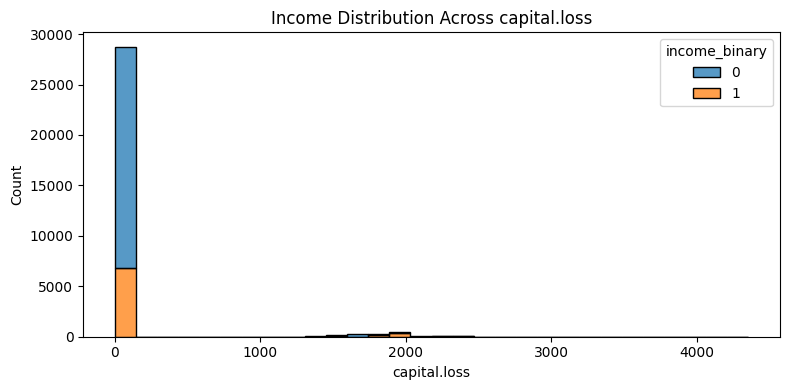

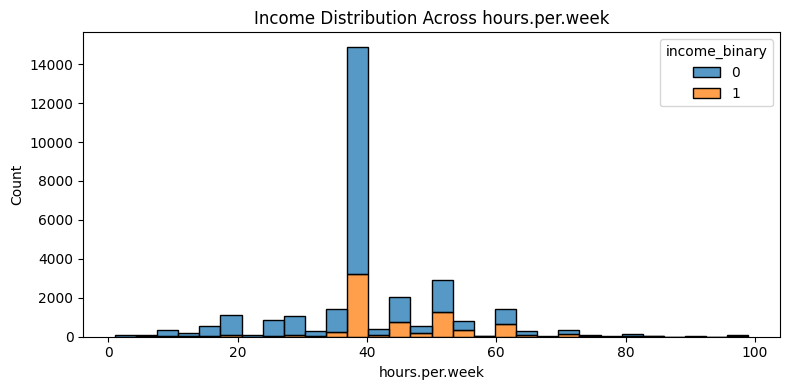

In [21]:
# plot numerical columns
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df_clean, x=col, hue='income_binary', multiple='stack', bins=30)
    plt.title(f"Income Distribution Across {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

1. When acquiring the summary statistic of the numeric variables, it can be seen that some variables (capital.gain, capital.loss, hours.per.week), assuming normally distributed, contains potential outliers
2. Correlation matrix shows that there are no other highly correlated predictors
3. There are categorical variables with class imbalances:
- Workclass has an imbalance on "private"
- Race has an imbalance on "white"
- Native Country has a big imbalance on "United-States"
4. There is an imbalance with the income as more people have an income of less than or equal to 50k
5. 2399 rows (around 7% of the data) were removed for the "convenience" of the model to be made since it is not ideal for LPM models to deal with NaN values (around 7% of a dataset of 34k+)
6. Noticed data loss on some variables upon dropping the rows, example is "Never-worked" for workclass (this was noticed when checking the basis variable for categorical beta coefficients)

## 2. Train-Test Split

In [22]:
df_categ = df_categ.drop(columns=['income'])  # column dropped (more like an extra step, could've replaced)

In [23]:
df_categ  # check

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_TrinadadTobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,132870,9,0,4356,18,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [24]:
# change the column names
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)

In [25]:
df_categ  # check the changes

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_binary,workclass_Local_gov,workclass_Private,workclass_Self_emp_inc,...,native_country_Portugal,native_country_Puerto_Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_TrinadadTobago,native_country_United_States,native_country_Vietnam,native_country_Yugoslavia
1,82,132870,9,0,4356,18,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [26]:
df_categ_final = df_categ.astype(float)  # fix data error by making datatype consistent

In [27]:
# train-test splits
X = df_categ_final.loc[:, df_categ_final.columns != 'income_binary'].copy()
y = df_categ_final['income_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# check if the stratify strategy works/is good
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

income_binary
0.0    0.751078
1.0    0.248922
Name: proportion, dtype: float64
income_binary
0.0    0.751088
1.0    0.248912
Name: proportion, dtype: float64
income_binary
0.0    0.751036
1.0    0.248964
Name: proportion, dtype: float64


In [29]:
# add constant variables
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

1. Used 80/20 split to preserve the imbalances in the data in combination with the stratify strategy
2. We stratify the target (y/income_binary) to keep it consistent with (y, y_train, y_test) when splitting the data (if not may see an imbalanced splitting especially since our model's goal is to predict y). In addition, we don't stratify on any X variable due to its sheer number around 98 columns to pick or use

## 3. Fit the LPM

In [30]:
# run the model
lpm_model = sm.OLS(y_train, X_train_const)
lpm_results = lpm_model.fit()

In [31]:
print(lpm_results.summary())

                            OLS Regression Results                            
Dep. Variable:          income_binary   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     147.0
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:40:38   Log-Likelihood:                -8527.4
No. Observations:               24129   AIC:                         1.724e+04
Df Residuals:                   24034   BIC:                         1.801e+04
Df Model:                          94                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

1. A problem is that there are too many columns and may mess with some of the coefficients given (as seen with the very small value coefficients in some columns)
2. The R^2 score is low only displaying 0.365 and an adjusted of 0.363 (may be affected due to the sheer number of columns)
3. Some predictions are going out of the range [0, 1] which in the case of LPM would be impossible
4. Variables that pass the p > 0.05 are (workclass_Self_emp_inc, education_12th, education_1st_4th, education_7th_8th, education_9th, education_Bacherlors, education_Some_college, marital_status_Married_spouse_absent, marital_status_Never_married, marital_status_Separated, occupation_Armed_Forces, occupation_Priv_house_serv, all categories of race except race_White (possibly because of the imbalance), all categories of native countries except native_country_South)
5. To simplify number 4, All other categories, whether numerical or categorical, are significant except a majority of native_countries and race

## 4. Model Summary Interpretation

PREDICTION ANALYSIS - LINEAR PROBABILITY MODEL:
--------------------------------------------------
IMPOSSIBLE PREDICTIONS ANALYSIS:
Training set: 5011/24129 (20.8%) outside [0,1]
Test set: 1248/6033 (20.7%) outside [0,1]

PREDICTION STATISTICS:
-------------------------
Training predictions - Min: -0.3473, Max: 1.6923
Test predictions - Min: -0.3002, Max: 1.6171


C:\Users\Thom\AppData\Local\Temp\ipykernel_21528\3149269274.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(survival_groups, labels=['0 (<=50k)', '1 (>50k)'])


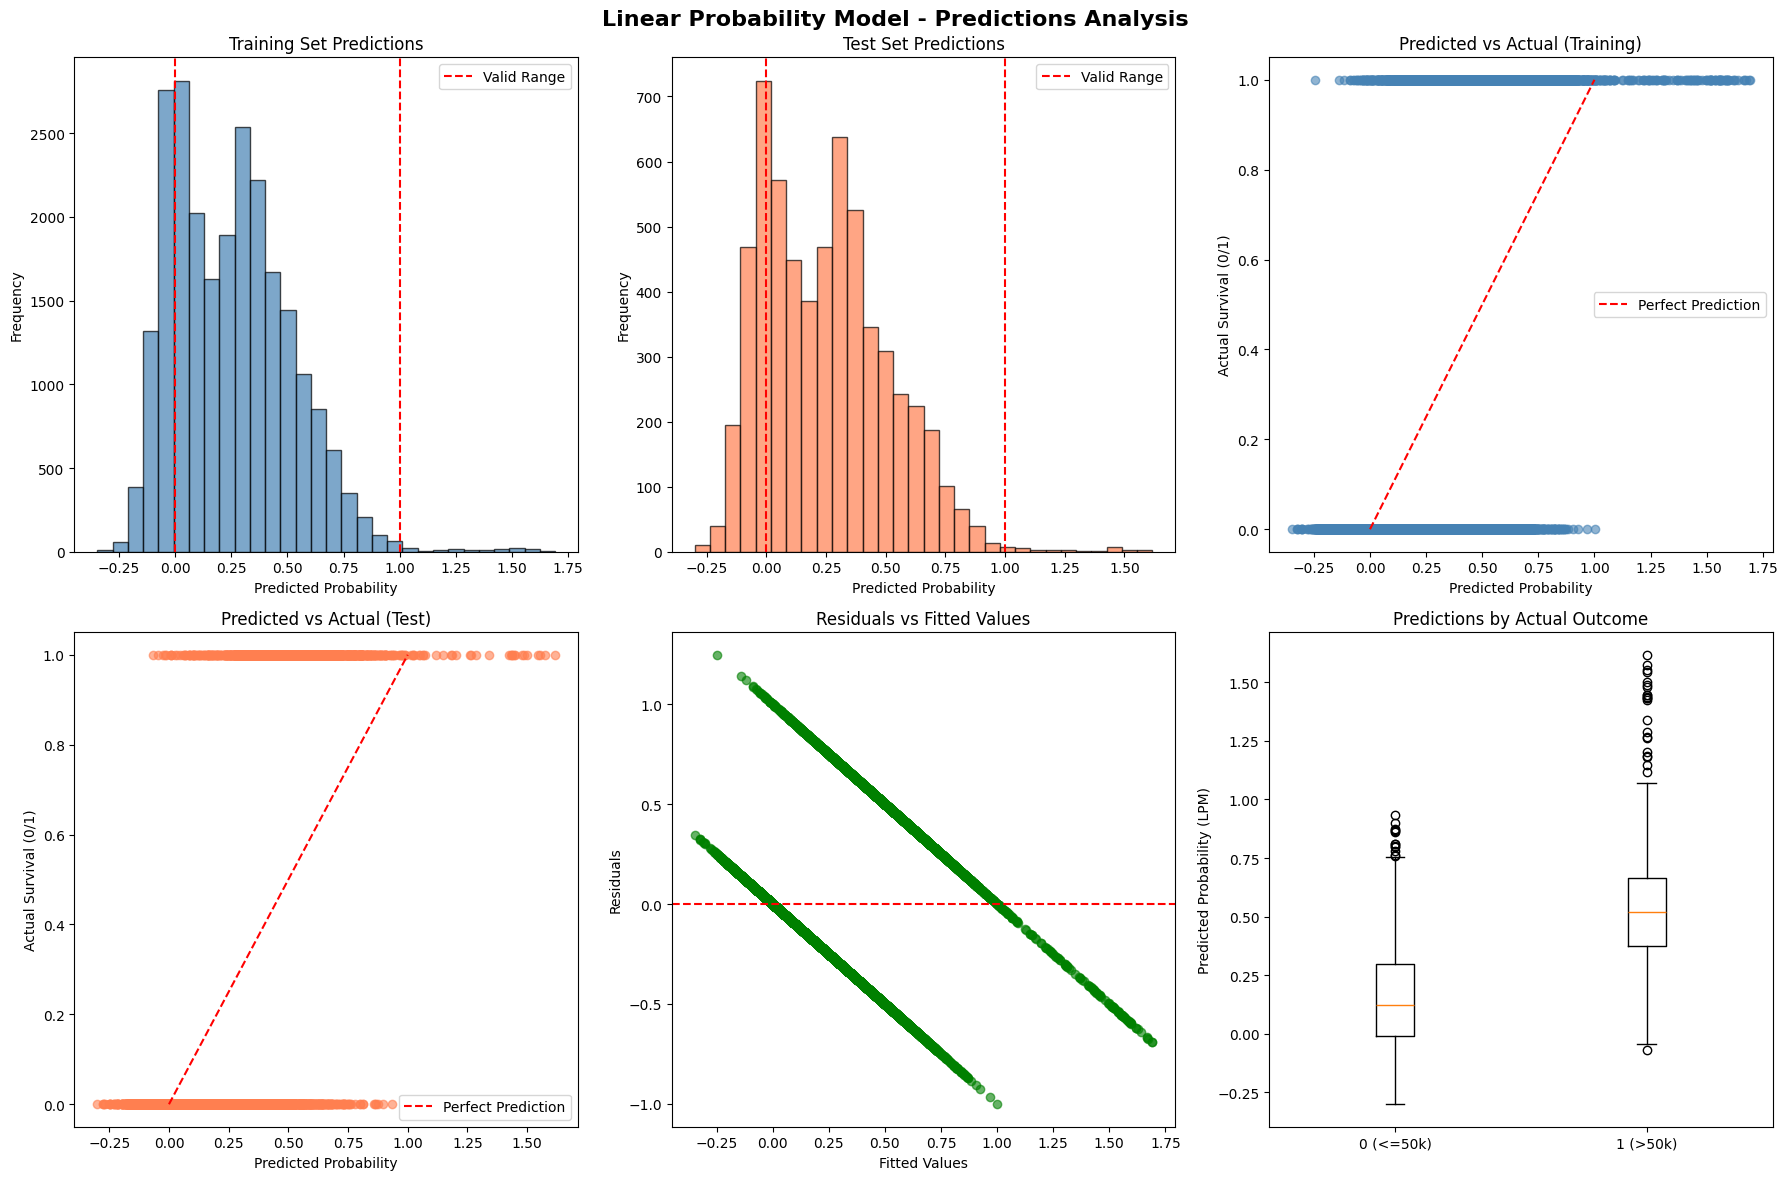


MOST EXTREME PREDICTIONS:
Lowest prediction: -0.3473
Highest prediction: 1.6923


In [32]:
# Model Predictions
y_pred_lpm_train = lpm_results.predict(X_train_const)
y_pred_lpm_test = lpm_results.predict(X_test_const)

print("PREDICTION ANALYSIS - LINEAR PROBABILITY MODEL:")
print("-" * 50)

# Check for impossible predictions (outside [0,1])
train_impossible = ((y_pred_lpm_train < 0) | (y_pred_lpm_train > 1)).sum()
test_impossible = ((y_pred_lpm_test < 0) | (y_pred_lpm_test > 1)).sum()

print(f"IMPOSSIBLE PREDICTIONS ANALYSIS:")
print(f"Training set: {train_impossible}/{len(y_pred_lpm_train)} ({train_impossible/len(y_pred_lpm_train)*100:.1f}%) outside [0,1]")
print(f"Test set: {test_impossible}/{len(y_pred_lpm_test)} ({test_impossible/len(y_pred_lpm_test)*100:.1f}%) outside [0,1]")

print(f"\nPREDICTION STATISTICS:")
print("-" * 25)
print(f"Training predictions - Min: {y_pred_lpm_train.min():.4f}, Max: {y_pred_lpm_train.max():.4f}")
print(f"Test predictions - Min: {y_pred_lpm_test.min():.4f}, Max: {y_pred_lpm_test.max():.4f}")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Linear Probability Model - Predictions Analysis', fontsize=16, fontweight='bold')

# 1. Histogram of training predictions
ax1 = axes[0, 0]
ax1.hist(y_pred_lpm_train, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', label='Valid Range')
ax1.axvline(1, color='red', linestyle='--')
ax1.set_title('Training Set Predictions')
ax1.set_xlabel('Predicted Probability')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Histogram of test predictions
ax2 = axes[0, 1]
ax2.hist(y_pred_lpm_test, bins=30, alpha=0.7, color='coral', edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', label='Valid Range')
ax2.axvline(1, color='red', linestyle='--')
ax2.set_title('Test Set Predictions')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Predicted vs Actual - Training
ax3 = axes[0, 2]
ax3.scatter(y_pred_lpm_train, y_train, alpha=0.6, color='steelblue')
ax3.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
ax3.set_title('Predicted vs Actual (Training)')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Actual Survival (0/1)')
ax3.legend()

# 4. Predicted vs Actual - Test
ax4 = axes[1, 0]
ax4.scatter(y_pred_lpm_test, y_test, alpha=0.6, color='coral')
ax4.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
ax4.set_title('Predicted vs Actual (Test)')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Actual Survival (0/1)')
ax4.legend()

# 5. Residuals vs Fitted
ax5 = axes[1, 1]
residuals_train = y_train - y_pred_lpm_train
ax5.scatter(y_pred_lpm_train, residuals_train, alpha=0.6, color='green')
ax5.axhline(0, color='red', linestyle='--')
ax5.set_title('Residuals vs Fitted Values')
ax5.set_xlabel('Fitted Values')
ax5.set_ylabel('Residuals')

# 6. Box plot by actual survival
ax6 = axes[1, 2]
survival_groups = [y_pred_lpm_test[y_test == 0], y_pred_lpm_test[y_test == 1]]
ax6.boxplot(survival_groups, labels=['0 (<=50k)', '1 (>50k)'])
ax6.set_title('Predictions by Actual Outcome')
ax6.set_ylabel('Predicted Probability (LPM)')

plt.tight_layout()
plt.show()

# Identify most problematic predictions
if train_impossible > 0 or test_impossible > 0:
    print(f"\nMOST EXTREME PREDICTIONS:")
    all_predictions = np.concatenate([y_pred_lpm_train, y_pred_lpm_test])
    print(f"Lowest prediction: {all_predictions.min():.4f}")
    print(f"Highest prediction: {all_predictions.max():.4f}")

#### Model Summary:
- R^2 Score: 0.365
- Adjusted R^2 Score: 0.363
- F-Statistic: 147.0
- Prob (F-Statistic): <0.00001
- Log-Likelihood: -8527.4
- AIC: 1.724e+04
- BIC: 1.801e+04

#### Model Interpretations:
- Even with the low R^2 score (model doesnt fit the data too well), there is still significance in the model with the F-Statistic with a p < 0.05 (meaning the model is still useful despite the low R^2 score like accuracy, precision, recall, specificity could still be good)
- The log-likelihood is in the negatives (really low), AIC and BIC are showing low decimals (these three measure the "badness" of the model, so low badness = model is decent to good)

#### Prediction Interpretations:
- Model predictions show that there are a handful of error predictions (not within 0 < P < 1, where P is the prediction value)
- This include the outliers in the boxplot, bars beyond the redlines [0, 1]
- The model having a 20% impossible analysis signifies that this model may not be appropriate for this dataset's analysis
- Boxplot shows many outliers in predictions by actual outcome (be it type 1 or type 2)

## 5. Classification Metrics

LINEAR PROBABILITY MODEL - CLASSIFICATION PERFORMANCE:
-------------------------------------------------------
Using threshold: 0.5
-----------------------------------
TRAINING SET CONFUSION MATRIX:
-----------------------------------
                     Predicted
                      0 (<=50k)         1 (>50k)
Actual 0 (<=50k)   17074            1049
       1 (>50k)    2931            3075

TEST SET CONFUSION MATRIX:
------------------------------
                    Predicted
                    0 (<=50k)         1 (>50k)
Actual 0 (<=50k)  4285             246
       1 (>50k)    706             796

KEY PERFORMANCE METRICS
        Metric  Training    Test
0     Accuracy    0.8351  0.8422
1    Precision    0.7456  0.7639
2       Recall    0.5120  0.5300
3  Specificity    0.9421  0.9457
4     F1-Score    0.6071  0.6258

DETAILED INTERPRETATION:
-------------------------
1. ACCURACY (0.842):
   → 84.2% of all predictions are correct

2. PRECISION (0.764):
   → Of people predicted to h

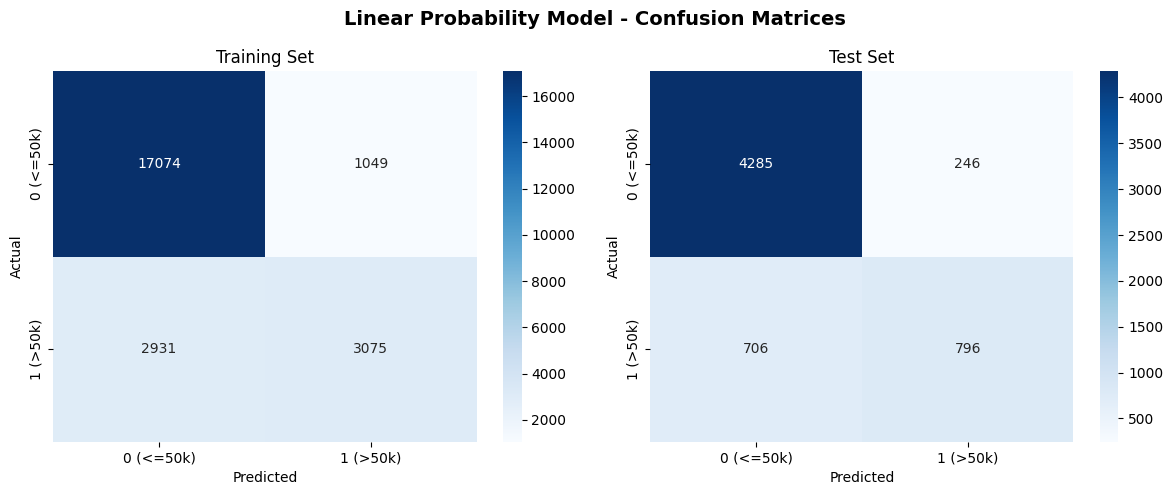

In [33]:
print("LINEAR PROBABILITY MODEL - CLASSIFICATION PERFORMANCE:")
print("-" * 55)

# Convert probabilities to binary predictions using 0.5 threshold
threshold = 0.5
y_pred_binary_train = (y_pred_lpm_train >= threshold).astype(int)
y_pred_binary_test = (y_pred_lpm_test >= threshold).astype(int)

print(f"Using threshold: {threshold}")

# Training set confusion matrix
cm_train = confusion_matrix(y_train, y_pred_binary_train)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()

print("-" * 35)
print(f"TRAINING SET CONFUSION MATRIX:")
print("-" * 35)
print("                     Predicted")
print("                      0 (<=50k)         1 (>50k)")
print(f"Actual 0 (<=50k)   {tn_train:4d}            {fp_train:4d}")
print(f"       1 (>50k)    {fn_train:4d}            {tp_train:4d}")

# Test set confusion matrix
cm_test = confusion_matrix(y_test, y_pred_binary_test)
tn_test, fp_test, fn_test, tp_test = cm_test.ravel()

print(f"\nTEST SET CONFUSION MATRIX:")
print("-" * 30)
print("                    Predicted")
print("                    0 (<=50k)         1 (>50k)")
print(f"Actual 0 (<=50k)  {tn_test:4d}            {fp_test:4d}")
print(f"       1 (>50k)   {fn_test:4d}            {tp_test:4d}")

# Calculate all metrics
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Calculate specificity manually
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1
    }

train_metrics = calculate_metrics(y_train, y_pred_binary_train)
test_metrics = calculate_metrics(y_test, y_pred_binary_test)

# Create metrics comparison table
print("\n" + "="*40)
print("KEY PERFORMANCE METRICS")
print("="*40)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score'],
    'Training': [
        train_metrics['accuracy'],
        train_metrics['precision'],
        train_metrics['recall'],
        train_metrics['specificity'],
        train_metrics['f1']
    ],
    'Test': [
        test_metrics['accuracy'],
        test_metrics['precision'],
        test_metrics['recall'],
        test_metrics['specificity'],
        test_metrics['f1']
    ]
})

print(metrics_df.round(4))

print(f"\nDETAILED INTERPRETATION:")
print("-" * 25)
print(f"1. ACCURACY ({test_metrics['accuracy']:.3f}):")
print(f"   → {test_metrics['accuracy']:.1%} of all predictions are correct")

print(f"\n2. PRECISION ({test_metrics['precision']:.3f}):")
print(f"   → Of people predicted to have an income of >50k, {test_metrics['precision']:.1%} actually do")

print(f"\n3. RECALL ({test_metrics['recall']:.3f}):")
print(f"   → Of people who's income is >50k, we identified {test_metrics['recall']:.1%}")

print(f"\n4. SPECIFICITY ({test_metrics['specificity']:.3f}):")
print(f"   → Of people who actually has an income <=50k, we correctly identified {test_metrics['specificity']:.1%}")

print(f"\n5. F1-SCORE ({test_metrics['f1']:.3f}):")
print(f"   → Balanced measure combining precision and recall (balance of type 1 and type 2 errors, model catches them/see them)")

# Visualization of confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Linear Probability Model - Confusion Matrices', fontsize=14, fontweight='bold')

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['0 (<=50k)', '1 (>50k)'], yticklabels=['0 (<=50k)', '1 (>50k)'])
axes[0].set_title('Training Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Test confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['0 (<=50k)', '1 (>50k)'], yticklabels=['0 (<=50k)', '1 (>50k)'])
axes[1].set_title('Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


- 5% tolerance of the difference between the scores of training and test sets
- Since the model didn't cross the tolernace its ok and the performance of test set is higher (unseen data) that may imply that the model is doing good

## 6. Coefficient Interpretation

#### Top 5 Coefficients:
- workclass_Local_gov [-0.1071, negative], workclass_Self_emp_not_inc [-0.1342, negative], workclass_State_gov [-0.1142, negative], education_Doctorate [0.1251, positive], occupation_Exec_managerial [0.1211, positive] (all have a p value lower than 0.0001, the coefficient of each variable is in the brackets)
- the categorical variable workclass displays many variables that has a lower p value than 0.0001 this can signify strong relationship for prediction

#### Beta Coefficient Interpretation:
- Being in a Local Government workclass is associated with a 0.1071 point lower probability of having an income higher than 50k compared to a Federal Government workclass
- Being in a Self Employed Not Incorporated workclass is associated with a 0.1342 point lower probability of having an income higher than 50k compared to a Federal Government workclass
- Being in a State Government workclass is associated with a 0.1142 point lower probability of having an income higher than 50k compared to a Federal Government workclass
- Having a Doctorate education is associated with a 0.1251 point higher probability of having an income higher than 50k compared to a 10th Grade education
- Having an Executive Manegerial occupation is associated with a 0.1211 point higher probability of having an income higher than 50k compared to an Admin Clerical occupation

#### Real World Comparison:
- Higher positions mean higher salary, Federal Government (higher probability of >50k salary) -> State Government -> Local Government -> Self Employed Not Incorporated (lower probability of >50k salary)
- Having a higher education may mean better opportunities for higher job positions, Doctorate -> 10th Grade (same format as previous)
- Similar to positions the higher the occupation, the higher likelihood for high salary Executive Manager -> Clerk Admin (same format as previous)

# Start of Logistic Regression Model and Generalized Linear Model

## 1. Feature Selection Pipeline

In [34]:
# trying a tuned model since original model is returning a singular matrix error
# Extract features with p-value > 0.05 (excluding 'const')
features_to_remove = []
for feature, pval in lpm_results.pvalues.items():
    if feature != 'const' and pval > 0.05:
        features_to_remove.append(feature)

print(f"Features to remove (p > 0.05): {len(features_to_remove)}")
print(features_to_remove)

# Remove these features from your dataset
df_categ_final2 = df_categ_final.drop(columns=features_to_remove)
print(f"Original shape: {df_categ_final.shape}")
print(f"Tuned shape: {df_categ_final2.shape}")

Features to remove (p > 0.05): 55
['workclass_Self_emp_inc', 'education_11th', 'education_12th', 'education_1st_4th', 'education_7th_8th', 'education_9th', 'education_Bachelors', 'education_Some_college', 'marital_status_Married_spouse_absent', 'marital_status_Never_married', 'marital_status_Separated', 'occupation_Armed_Forces', 'occupation_Priv_house_serv', 'race_Asian_Pac_Islander', 'race_Black', 'race_Other', 'native_country_Canada', 'native_country_China', 'native_country_Columbia', 'native_country_Cuba', 'native_country_Dominican_Republic', 'native_country_Ecuador', 'native_country_El_Salvador', 'native_country_England', 'native_country_France', 'native_country_Germany', 'native_country_Greece', 'native_country_Guatemala', 'native_country_Haiti', 'native_country_Holand_Netherlands', 'native_country_Honduras', 'native_country_Hong', 'native_country_Hungary', 'native_country_India', 'native_country_Iran', 'native_country_Ireland', 'native_country_Italy', 'native_country_Jamaica', '

- These features were removed because their p-values are greater than 0.05

In [35]:
df_categ_final2  # check

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_binary,workclass_Local_gov,workclass_Private,workclass_Self_emp_not_inc,...,occupation_Tech_support,occupation_Transport_moving,relationship_Not_in_family,relationship_Other_relative,relationship_Own_child,relationship_Unmarried,relationship_Wife,race_White,sex_Male,native_country_South
1,82.0,132870.0,9.0,0.0,4356.0,18.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,54.0,140359.0,4.0,0.0,3900.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,41.0,264663.0,10.0,0.0,3900.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5,34.0,216864.0,9.0,0.0,3770.0,45.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,38.0,150601.0,6.0,0.0,3770.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22.0,310152.0,10.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
32557,27.0,257302.0,12.0,0.0,0.0,38.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
32558,40.0,154374.0,9.0,0.0,0.0,40.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
32559,58.0,151910.0,9.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [36]:
# tuned model from 97 columns to 42
X = df_categ_final2.loc[:, df_categ_final2.columns != 'income_binary'].copy()
y = df_categ_final2['income_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [38]:
lpm_model = sm.OLS(y_train, X_train_const)
lpm_results = lpm_model.fit()

In [39]:
print(lpm_results.summary())  # used to check if we missed any variables (dropped)

                            OLS Regression Results                            
Dep. Variable:          income_binary   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     334.8
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:40:40   Log-Likelihood:                -8565.6
No. Observations:               24129   AIC:                         1.722e+04
Df Residuals:                   24087   BIC:                         1.756e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

- No more p-value greater than 0.05

In [40]:
# Calculate Variance Inflation Factors (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) 
                   for i in range(X_train.shape[1])]

print("MULTICOLLINEARITY ASSESSMENT")
print("="*50)
print("Variance Inflation Factors (VIF):")
print(vif_data.round(3))

print(f"\nInterpretation Notes:")
print(f"  VIF > 5:     Remove the Feature")

# Identify problematic variables
high_vif = vif_data[vif_data['VIF'] > 5]
if not high_vif.empty:
    print(f"\n⚠ Variables with elevated VIF (> 5):")
    for _, row in high_vif.iterrows():
        print(f"  {row['Variable']}: {row['VIF']:.3f}")
else:
    print(f"\n✓ No concerning multicollinearity detected (all VIF < 5)")

MULTICOLLINEARITY ASSESSMENT
Variance Inflation Factors (VIF):
                             Variable     VIF
0                                 age  12.852
1                              fnlwgt   4.228
2                       education_num  32.036
3                        capital_gain   1.084
4                        capital_loss   1.072
5                      hours_per_week  14.831
6                 workclass_Local_gov   2.127
7                   workclass_Private  11.940
8          workclass_Self_emp_not_inc   2.294
9                 workclass_State_gov   1.655
10              workclass_Without_pay   1.012
11                  education_5th_6th   1.151
12               education_Assoc_acdm   1.107
13                education_Assoc_voc   1.116
14                education_Doctorate   1.189
15                  education_HS_grad   1.808
16                  education_Masters   1.374
17                education_Preschool   1.042
18              education_Prof_school   1.250
19   marital_stat

In [41]:
# Copy original dataset
df_categ_final3 = df_categ_final2.copy()

high_vif_vars = [
    "age",
    "education_num",
    "hours_per_week",
    "workclass_Private",
    "marital_status_Married_civ_spouse",
    "relationship_Not_in_family",
    "relationship_Own_child",
    "relationship_Unmarried",
    "race_White",
    "sex_Male"
]

# Drop only these
df_categ_final3.drop(columns=high_vif_vars, inplace=True, errors="ignore")

print("Dropped Due to Multicollinearity:")
for col in high_vif_vars:
    if col in df_categ_final2.columns:
        print(" -", col)

print("\nNew df_categ_final3 shape:", df_categ_final3.shape)

Dropped Due to Multicollinearity:
 - age
 - education_num
 - hours_per_week
 - workclass_Private
 - marital_status_Married_civ_spouse
 - relationship_Not_in_family
 - relationship_Own_child
 - relationship_Unmarried
 - race_White
 - sex_Male

New df_categ_final3 shape: (30162, 32)


In [42]:
df_categ_final3  # check

,fnlwgt,capital_gain,capital_loss,income_binary,workclass_Local_gov,workclass_Self_emp_not_inc,workclass_State_gov,workclass_Without_pay,education_5th_6th,education_Assoc_acdm,...,occupation_Machine_op_inspct,occupation_Other_service,occupation_Prof_specialty,occupation_Protective_serv,occupation_Sales,occupation_Tech_support,occupation_Transport_moving,relationship_Other_relative,relationship_Wife,native_country_South
1,132870.0,0.0,4356.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,140359.0,0.0,3900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,264663.0,0.0,3900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,216864.0,0.0,3770.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,150601.0,0.0,3770.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,310152.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
32557,257302.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
32558,154374.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32559,151910.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
# Calculate Variance Inflation Factors (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = df_categ_final3.columns
vif_data["VIF"] = [variance_inflation_factor(df_categ_final3.values, i) 
                   for i in range(df_categ_final3.shape[1])]

print("MULTICOLLINEARITY ASSESSMENT")
print("="*50)
print("Variance Inflation Factors (VIF):")
print(vif_data.round(3))

print(f"\nInterpretation Notes:")
print(f"  VIF > 5:     Remove the Feature")

# Identify problematic variables
high_vif = vif_data[vif_data['VIF'] > 5]
if not high_vif.empty:
    print(f"\n⚠ Variables with elevated VIF (> 5):")
    for _, row in high_vif.iterrows():
        print(f"  {row['Variable']}: {row['VIF']:.3f}")
else:
    print(f"\n✓ No concerning multicollinearity detected (all VIF < 5)")

MULTICOLLINEARITY ASSESSMENT
Variance Inflation Factors (VIF):
                            Variable    VIF
0                             fnlwgt  3.130
1                       capital_gain  1.108
2                       capital_loss  1.081
3                      income_binary  1.679
4                workclass_Local_gov  1.217
5         workclass_Self_emp_not_inc  1.204
6                workclass_State_gov  1.098
7              workclass_Without_pay  1.004
8                  education_5th_6th  1.038
9               education_Assoc_acdm  1.057
10               education_Assoc_voc  1.083
11               education_Doctorate  1.116
12                 education_HS_grad  1.647
13                 education_Masters  1.253
14               education_Preschool  1.008
15             education_Prof_school  1.187
16  marital_status_Married_AF_spouse  1.004
17            marital_status_Widowed  1.034
18           occupation_Craft_repair  1.498
19        occupation_Exec_managerial  1.524
20        occ

In [44]:
print(df_categ_final3.shape)

(30162, 32)


In [45]:
# tuned model from 42 columns to 32
X = df_categ_final3.loc[:, df_categ_final3.columns != 'income_binary'].copy()
y = df_categ_final3['income_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [47]:
lpm_model = sm.OLS(y_train, X_train_const)
lpm_results = lpm_model.fit()

In [48]:
print(lpm_results.summary())

                            OLS Regression Results                            
Dep. Variable:          income_binary   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     204.7
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:40:43   Log-Likelihood:                -11186.
No. Observations:               24129   AIC:                         2.244e+04
Df Residuals:                   24097   BIC:                         2.270e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [49]:
# Retune since there are still variables with p-value > 0.05
# Extract features with p-value > 0.05 (excluding 'const')
features_to_remove = []
for feature, pval in lpm_results.pvalues.items():
    if feature != 'const' and pval > 0.05:
        features_to_remove.append(feature)

print(f"Features to remove (p > 0.05): {len(features_to_remove)}")
print(features_to_remove)

# Remove these features from your dataset
df_categ_final4 = df_categ_final3.drop(columns=features_to_remove)
print(f"Original shape: {df_categ_final3.shape}")
print(f"Tuned shape: {df_categ_final4.shape}")

Features to remove (p > 0.05): 8
['fnlwgt', 'workclass_Self_emp_not_inc', 'workclass_Without_pay', 'education_Assoc_acdm', 'education_Assoc_voc', 'marital_status_Married_AF_spouse', 'occupation_Farming_fishing', 'occupation_Machine_op_inspct']
Original shape: (30162, 32)
Tuned shape: (30162, 24)


- These features were removed because their p-values are greater than 0.05

In [50]:
# tuned model from 32 columns to 24
X = df_categ_final4.loc[:, df_categ_final4.columns != 'income_binary'].copy()
y = df_categ_final4['income_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [52]:
lpm_model = sm.OLS(y_train, X_train_const)
lpm_results = lpm_model.fit()

In [53]:
print(lpm_results.summary())

                            OLS Regression Results                            
Dep. Variable:          income_binary   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     275.5
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:40:43   Log-Likelihood:                -11191.
No. Observations:               24129   AIC:                         2.243e+04
Df Residuals:                   24105   BIC:                         2.262e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [54]:
# Fit LOGIT model
logit_model = sm.Logit(y_train, X_train_const)
logit_results = logit_model.fit()

print(f"\nMODEL FITTING COMPLETE:")
print(f"- Estimation method: Maximum Likelihood Estimation (MLE)")
print(f"- Number of observations: {logit_results.nobs}")
print(f"- Number of parameters: {len(logit_results.params)}")
print(f"- Degrees of freedom: {logit_results.df_resid}")
print(f"- Convergence achieved: {'Yes' if logit_results.mle_retvals['converged'] else 'No'}")
print(f"- Number of iterations: {logit_results.mle_retvals.get('iterations', 'N/A')}")

Optimization terminated successfully.
         Current function value: 0.428648
         Iterations 18

MODEL FITTING COMPLETE:
- Estimation method: Maximum Likelihood Estimation (MLE)
- Number of observations: 24129
- Number of parameters: 24
- Degrees of freedom: 24105.0
- Convergence achieved: Yes
- Number of iterations: 18


In [55]:
print(logit_results.summary())

                           Logit Regression Results                           
Dep. Variable:          income_binary   No. Observations:                24129
Model:                          Logit   Df Residuals:                    24105
Method:                           MLE   Df Model:                           23
Date:                Tue, 17 Feb 2026   Pseudo R-squ.:                  0.2361
Time:                        08:40:43   Log-Likelihood:                -10343.
converged:                       True   LL-Null:                       -13540.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.1353      0.048    -44.267      0.000      -2.230      -2.041
capital_gain                     0.0003   1.12e-05     30.193      0.000     

In [56]:
# Fit GLM model
glm_binomial = sm.GLM(y_train, X_train_const, family=sm.families.Binomial()).fit()

In [57]:
print(glm_binomial.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          income_binary   No. Observations:                24129
Model:                            GLM   Df Residuals:                    24105
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10343.
Date:                Tue, 17 Feb 2026   Deviance:                       20686.
Time:                        08:40:44   Pearson chi2:                 4.48e+05
No. Iterations:                    22   Pseudo R-squ. (CS):             0.2328
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [58]:
# LOGIT
logit_model = sm.Logit(y_train, X_train_const)

# Fit with robust covariance (Huber-White)
logit_results = logit_model.fit(cov_type='HC3', disp=False)

# GLM (Binomial) also supports robust SE
glm_model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial())
glm_results = glm_model.fit(cov_type='HC3')

In [59]:
print(logit_results.summary())

                           Logit Regression Results                           
Dep. Variable:          income_binary   No. Observations:                24129
Model:                          Logit   Df Residuals:                    24105
Method:                           MLE   Df Model:                           23
Date:                Tue, 17 Feb 2026   Pseudo R-squ.:                  0.2361
Time:                        08:40:44   Log-Likelihood:                -10343.
converged:                       True   LL-Null:                       -13540.
Covariance Type:                  HC3   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.1353      0.047    -45.635      0.000      -2.227      -2.044
capital_gain                     0.0003   1.32e-05     25.623      0.000     

In [60]:
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          income_binary   No. Observations:                24129
Model:                            GLM   Df Residuals:                    24105
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10343.
Date:                Tue, 17 Feb 2026   Deviance:                       20686.
Time:                        08:40:44   Pearson chi2:                 4.48e+05
No. Iterations:                    22   Pseudo R-squ. (CS):             0.2328
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

# 2. Three-Model Comparison Training

In [61]:
# dropped because coeff was super high -42 and -21
df_categ_final4 = df_categ_final4.drop(columns=["education_Preschool"])

In [62]:
# Retrain
X = df_categ_final4.loc[:, df_categ_final4.columns != 'income_binary'].copy()
y = df_categ_final4['income_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [63]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [64]:
lpm_model = sm.OLS(y_train, X_train_const)
lpm_results = lpm_model.fit()

In [65]:
# LOGIT
logit_model = sm.Logit(y_train, X_train_const)

# Fit with robust covariance (Huber-White)
logit_results = logit_model.fit(cov_type='HC3', disp=False)

# GLM (Binomial) with robust SE
glm_model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial())
glm_results = glm_model.fit(cov_type='HC3')

In [66]:
print(lpm_results.summary())
print(logit_results.summary())
print(glm_results.summary())

                            OLS Regression Results                            
Dep. Variable:          income_binary   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     287.8
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:40:44   Log-Likelihood:                -11193.
No. Observations:               24129   AIC:                         2.243e+04
Df Residuals:                   24106   BIC:                         2.262e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [67]:
# Show all coef of the three models
coef_compare = pd.DataFrame({
    "Feature": df_categ_final4.columns,
    "LPM": lpm_results.params.values,
    "LOGIT": logit_results.params.values,
    "GLM_Binomial": glm_results.params.values
})

# Add difference column (LOGIT - GLM)
coef_compare["LOGIT_minus_GLM"] = coef_compare["LOGIT"] - coef_compare["GLM_Binomial"]

# Add difference column (LPM - LOGIT)
coef_compare["LPM_minus_LOGIT"] = coef_compare["LPM"] - coef_compare["LOGIT"]

# Set feature as index for clean display
coef_compare.set_index("Feature", inplace=True)

# Pretty print
pd.set_option("display.float_format", "{:.6f}".format)
print("\nMODEL COEFFICIENT COMPARISON")
print("="*80)
print(coef_compare)


MODEL COEFFICIENT COMPARISON
                                   LPM     LOGIT  GLM_Binomial  \
Feature                                                          
capital_gain                  0.126458 -2.141401     -2.141401   
capital_loss                  0.000010  0.000339      0.000339   
income_binary                 0.000120  0.000702      0.000702   
workclass_Local_gov          -0.030005 -0.199318     -0.199318   
workclass_State_gov          -0.057399 -0.362166     -0.362166   
education_5th_6th            -0.083734 -1.165287     -1.165287   
education_Doctorate           0.357777  1.733051      1.733051   
education_HS_grad            -0.039356 -0.280980     -0.280980   
education_Masters             0.195133  0.872680      0.872680   
education_Prof_school         0.317128  1.701393      1.701393   
marital_status_Widowed       -0.082735 -0.886070     -0.886070   
occupation_Craft_repair       0.103038  0.786889      0.786889   
occupation_Exec_managerial    0.282126  1.6044

- capital_gain differed the most between the LPM and (LOGIT & GLM) with a coefficient difference of 2.267859
- the signs are consistent across the three models except capital_gain
- there is no difference between LOGIT and GLM as the difference in their coefficients are 0

In [68]:
# Predict using the three models
lpm_train_pred_prob = lpm_results.predict(X_train_const)
lpm_test_pred_prob = lpm_results.predict(X_test_const)

# Verify all predictions are in valid range
print(f"PREDICTION RANGE VERIFICATION:")
print(f"Training predictions - Min: {lpm_train_pred_prob.min():.6f}, Max: {lpm_train_pred_prob.max():.6f}")
print(f"Test predictions - Min: {lpm_test_pred_prob.min():.6f}, Max: {lpm_test_pred_prob.max():.6f}")
print(f"All predictions in [0,1]: {'✓ YES' if (lpm_train_pred_prob.min() >= 0 and lpm_train_pred_prob.max() <= 1 and lpm_test_pred_prob.min() >= 0 and lpm_test_pred_prob.max() <= 1) else '✗ NO'}")

print()

logit_train_pred_prob = logit_results.predict(X_train_const)
logit_test_pred_prob = logit_results.predict(X_test_const)

# Verify all predictions are in valid range
print(f"PREDICTION RANGE VERIFICATION:")
print(f"Training predictions - Min: {logit_train_pred_prob.min():.6f}, Max: {logit_train_pred_prob.max():.6f}")
print(f"Test predictions - Min: {logit_test_pred_prob.min():.6f}, Max: {logit_test_pred_prob.max():.6f}")
print(f"All predictions in [0,1]: {'✓ YES' if (logit_train_pred_prob.min() >= 0 and logit_train_pred_prob.max() <= 1 and logit_test_pred_prob.min() >= 0 and logit_test_pred_prob.max() <= 1) else '✗ NO'}")

print()

glm_train_pred_prob = glm_results.predict(X_train_const)
glm_test_pred_prob = glm_results.predict(X_test_const)

# Verify all predictions are in valid range
print(f"PREDICTION RANGE VERIFICATION:")
print(f"Training predictions - Min: {glm_train_pred_prob.min():.6f}, Max: {glm_train_pred_prob.max():.6f}")
print(f"Test predictions - Min: {glm_test_pred_prob.min():.6f}, Max: {glm_test_pred_prob.max():.6f}")
print(f"All predictions in [0,1]: {'✓ YES' if (glm_train_pred_prob.min() >= 0 and glm_train_pred_prob.max() <= 1 and glm_train_pred_prob.min() >= 0 and glm_train_pred_prob.max() <= 1) else '✗ NO'}")

PREDICTION RANGE VERIFICATION:
Training predictions - Min: -0.289768, Max: 1.860953
Test predictions - Min: -0.183760, Max: 1.968564
All predictions in [0,1]: ✗ NO

PREDICTION RANGE VERIFICATION:
Training predictions - Min: 0.000885, Max: 1.000000
Test predictions - Min: 0.002140, Max: 1.000000
All predictions in [0,1]: ✓ YES

PREDICTION RANGE VERIFICATION:
Training predictions - Min: 0.000885, Max: 1.000000
Test predictions - Min: 0.002140, Max: 1.000000
All predictions in [0,1]: ✓ YES


# 3. Model Performance Evaluation

In [69]:
# ============================================================================
# Generate Probabilities and Class Predictions
# ============================================================================
# LPM
lpm_test_pred_class = (lpm_test_pred_prob > 0.5).astype(int)

# Logistic Regression
logit_test_pred_class = (logit_test_pred_prob > 0.5).astype(int)

# GLM Binomial
glm_test_pred_class = (glm_test_pred_prob > 0.5).astype(int)

# ============================================================================
# Function to Display Confusion Matrix with Interpretation
# ============================================================================
def display_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{model_name} Confusion Matrix:")
    print(cm)
    print(f"  True Negatives (TN): {tn}")
    print(f"  False Positives (FP): {fp}")
    print(f"  False Negatives (FN): {fn}")
    print(f"  True Positives (TP): {tp}")
    
    print(f"Interpretation:")
    print(f"  - Correctly predicted negatives: {tn}")
    print(f"  - Incorrectly predicted positives: {fp}")
    print(f"  - Missed positives: {fn}")
    print(f"  - Correctly predicted positives: {tp}")

# ============================================================================
# Display Confusion Matrices for Test Set
# ============================================================================
for model_name, y_pred in zip(
    ['LPM', 'Logistic Regression', 'GLM Binomial'],
    [lpm_test_pred_class, logit_test_pred_class, glm_test_pred_class]
):
    display_confusion(y_test, y_pred, model_name)

# ============================================================================
# Function to Calculate Key Classification Metrics
# ============================================================================
def classification_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# ============================================================================
# Compute Metrics for All Models
# ============================================================================
metrics_dict = {
    'LPM': classification_metrics(y_test, lpm_test_pred_class),
    'Logistic Regression': classification_metrics(y_test, logit_test_pred_class),
    'GLM Binomial': classification_metrics(y_test, glm_test_pred_class)
}

# Create Comparison DataFrame
metrics_df = pd.DataFrame(metrics_dict).T  # transpose for better display
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]  # ordered columns

print("\nClassification Metrics Comparison (Test Set):")
print(metrics_df.round(4))


LPM Confusion Matrix:
[[4390  141]
 [1090  412]]
  True Negatives (TN): 4390
  False Positives (FP): 141
  False Negatives (FN): 1090
  True Positives (TP): 412
Interpretation:
  - Correctly predicted negatives: 4390
  - Incorrectly predicted positives: 141
  - Missed positives: 1090
  - Correctly predicted positives: 412

Logistic Regression Confusion Matrix:
[[4322  209]
 [ 906  596]]
  True Negatives (TN): 4322
  False Positives (FP): 209
  False Negatives (FN): 906
  True Positives (TP): 596
Interpretation:
  - Correctly predicted negatives: 4322
  - Incorrectly predicted positives: 209
  - Missed positives: 906
  - Correctly predicted positives: 596

GLM Binomial Confusion Matrix:
[[4322  209]
 [ 906  596]]
  True Negatives (TN): 4322
  False Positives (FP): 209
  False Negatives (FN): 906
  True Positives (TP): 596
Interpretation:
  - Correctly predicted negatives: 4322
  - Incorrectly predicted positives: 209
  - Missed positives: 906
  - Correctly predicted positives: 596

Cla

- The model that produced the most true negatives is LPM
- The model that produced the most false positives are LOGIT and GLM
- The model that produced the most false negatives is LPM
- The model that produced the most true positives are LOGIT and GLM
- The LOGIT and GLM model predicted more true positives whilst the LPM predicted more true negatives
- Like LOGIT and GLM see more positives while LPM sees more negatives

In [70]:
# ============================================================================
# LPM (Linear Probability Model)
# ============================================================================
print("LPM Model Statistics:")
print(f"  R-squared: {lpm_results.rsquared:.4f}")
print(f"  Log-likelihood: {lpm_results.llf:.4f}")
print(f"  AIC: {lpm_results.aic:.4f}\n")

# ============================================================================
# Logistic Regression (Logit)
# ============================================================================
print("Logistic Regression Model Statistics:")
print(f"  Pseudo R-squared (McFadden): {logit_results.prsquared:.4f}")
print(f"  Log-likelihood: {logit_results.llf:.4f}")
print(f"  AIC: {logit_results.aic:.4f}\n")

# ============================================================================
# GLM Binomial
# ============================================================================
glm_llf = glm_results.llf  # Log-likelihood of fitted model
glm_llf_null = glm_results.null_deviance / -2  # Approximate log-likelihood of null model

glm_pseudo_r2 = 1 - (glm_llf / glm_llf_null)  # McFadden's pseudo R-square

print("GLM Binomial Model Statistics:")
print(f"  Pseudo R-squared (McFadden): {glm_pseudo_r2:.4f}")
print(f"  Log-likelihood: {glm_results.llf:.4f}")
print(f"  AIC: {glm_results.aic:.4f}")

LPM Model Statistics:
  R-squared: 0.2080
  Log-likelihood: -11193.0963
  AIC: 22432.1927

Logistic Regression Model Statistics:
  Pseudo R-squared (McFadden): 0.2357
  Log-likelihood: -10348.0148
  AIC: 20742.0297

GLM Binomial Model Statistics:
  Pseudo R-squared (McFadden): 0.2357
  Log-likelihood: -10348.0148
  AIC: 20742.0297


- The model with the highest accuracy are Logistic Regression and GLM Binomial
- The model with the best balance of precision and recall are Logistic Regression and GLM Binomial
- Overall the model I would suggest is Logistic Regression as besides the classification metric it has the best r-squared score, better log-likelihood and AIC vs LPM

# 4. Best Model Interpretation

**Beta Coefficients**
- Best coefficients for the Logistic Regression are education_Prof_school (1.7014, positive), education_Doctorate (1.7331, positive), occupation_Exec_managerial (1.6044, positive)
- Their odds ratio education_Prof_school (5.48162), education_Doctorate (5.6582), occupation_Exec_managerial (4.9749)
Practical Interpretation:

**The strongest predictors of the outcome in the logistic regression model are education level and occupation type. Specifically, the variables with the largest positive coefficients are**
- education_Prof_school (β = 1.7014)
- education_Doctorate (β = 1.7331)
- occupation_Exec_managerial (β = 1.6044)
- In real life, higher education can mean a higher salary, including a high position in work relates to high salary

**Odds Ratio Interpretation:**
- education_Prof_school, Odds Ratio = 5.48162
- Individuals with a professional school education have a 5.48162 times higher odds to recieve a salary of >50k compared to the reference education level.
- education_Doctorate, Odds Ratio = 5.6582
- Individuals with a doctorate degree have about 5.6582 times higher odds to recieve a salary of >50k compared to the reference education level.
- occupation_Exec_managerial, Odds Ratio = 4.9749
- Individuals employed in executive or managerial occupations have nearly 4.9749 times higher odds to recieve a salary of >50k compared to the reference occupation level.

# 5. Overall Observations and Practical Insights

- Logistic Regression and GLM Binomial are closely similar except the pseudo r-square score. The rest like log-likelihood, AIC, classification metrics are similar in both models
- In terms of performance and interpretation Logistic Regression is the best since it was able to predict more true positives, had a better performance metric like r-squared, and better classification metrics vs LPM. LPM felt underperformed and not fit for the dataset. Its interpretations are mostly true negatives and some false negatives whilst having the worst performance amongst the three.
- I would choose LPM for simpler (fewer features) data, logistic regression for medium data with a valid binary outcome, glm (binomial) for more general work if you want to be flexible though it is similar logit.
- Important take away is that certain models have different and specific use cases. Even if they are closely similar like LOGIT and GLM they still serves different purposes and work/react differently depending on the data.

# KNN and Decision Trees

## 1. Data Preparation and Exploratory Data Analysis

In [71]:
# Load dataset and check size
data = fetch_openml(data_id=43436, as_frame=True)
df = data.frame
print(f"Data loaded successfully, Dataset Size: {len(df)} rows")

Data loaded successfully, Dataset Size: 32561 rows


In [72]:
df  # check dataset and shape

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,=50K


In [73]:
# check for null values
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [74]:
df_clean = df.dropna()  # Dropped null values to ensure safety for the LPM model (shows shape as well)
df_clean

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,=50K


In [75]:
# check if there are any more null values (if all NaN was dropped)
df_clean.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [76]:
# check data types per column
df_clean.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [77]:
# turn it into binary (0,1) instead of (<=50k, >50k)
df_clean["income_binary"] = (df_clean["income"] == "50K").astype(int)
df_clean["income_binary"].value_counts()

income_binary
0    22654
1     7508
Name: count, dtype: int64

C:\Users\Thom\AppData\Local\Temp\ipykernel_21528\1139628138.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


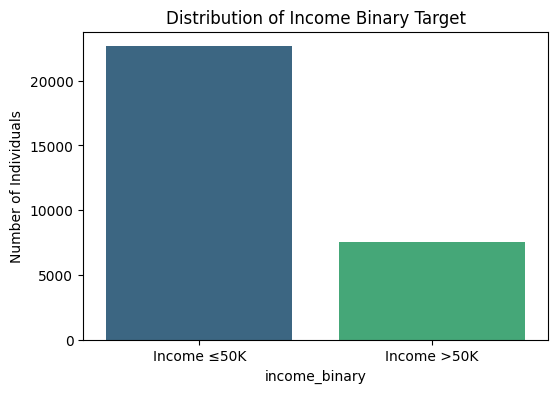

In [78]:
target_counts = df_clean['income_binary'].value_counts()

# ================================
# 1) Bar Plot
# ================================
plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.xticks([0,1], ['Income ≤50K', 'Income >50K'])
plt.ylabel('Number of Individuals')
plt.title('Distribution of Income Binary Target')
plt.show()

- theres more people with less than 50k salary than more than 50k salary

In [79]:
# create dummies while seperating categorical and numerical columns
categorical_cols = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]
numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
df_categ = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_categ

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,income_binary,workclass_Local-gov,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_TrinadadTobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,132870,9,0,4356,18,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,50K,1,False,True,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False


In [80]:
# summary statistic (noticed some potential outliers assuming normality)
df_clean.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,189793.833930,10.121312,1092.007858,88.372489,40.931238,0.248922
std,13.134665,105652.971529,2.549995,7406.346497,404.298370,11.979984,0.432396
min,17.000000,13769.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,117627.250000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,178425.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,237628.500000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1484705.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


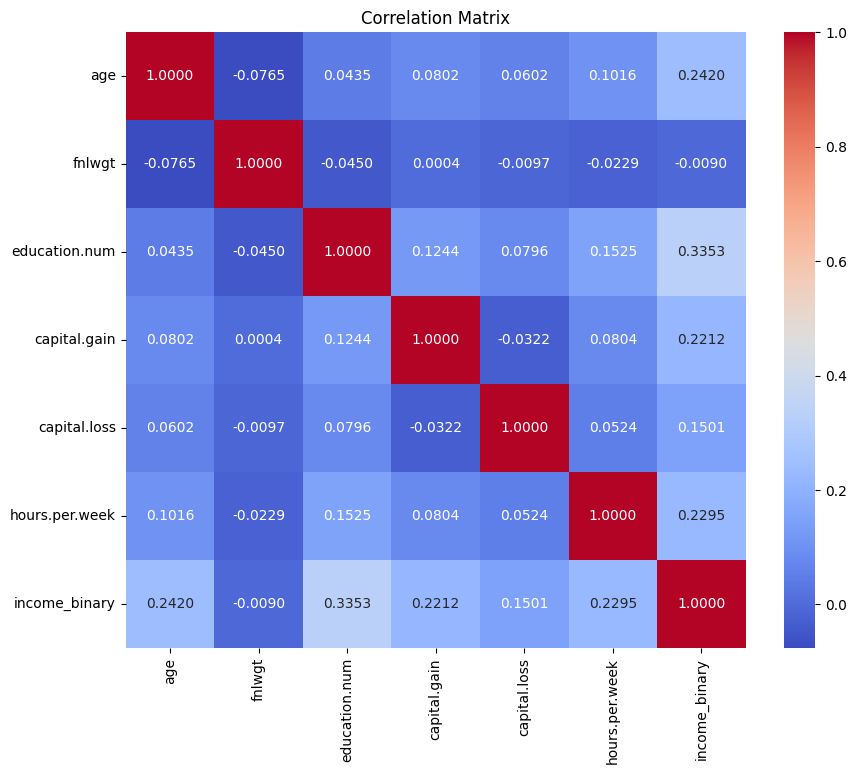

In [81]:
# check if other variables have a high correlation with each other (so far none too highly correlated)
numeric_df = df_clean.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

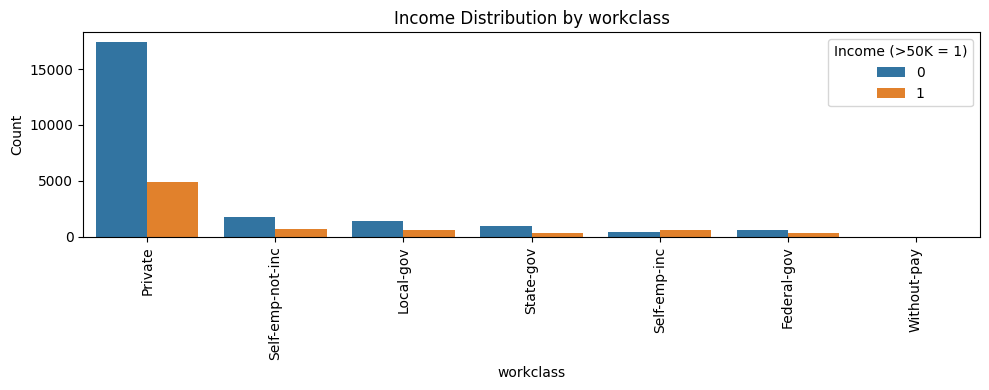

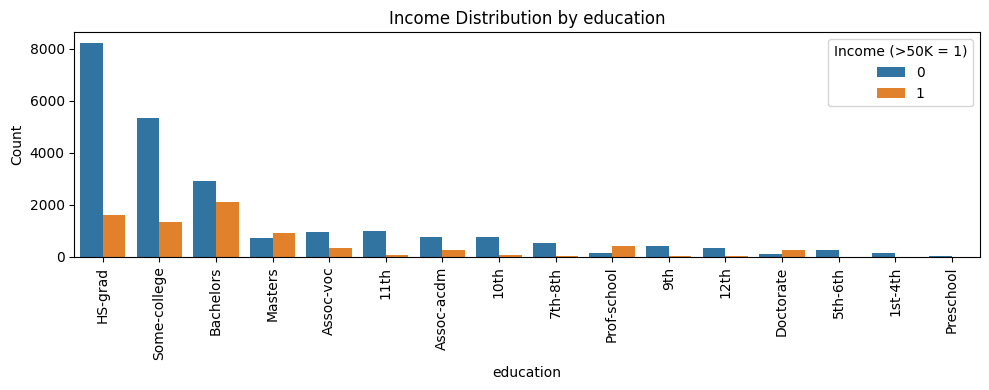

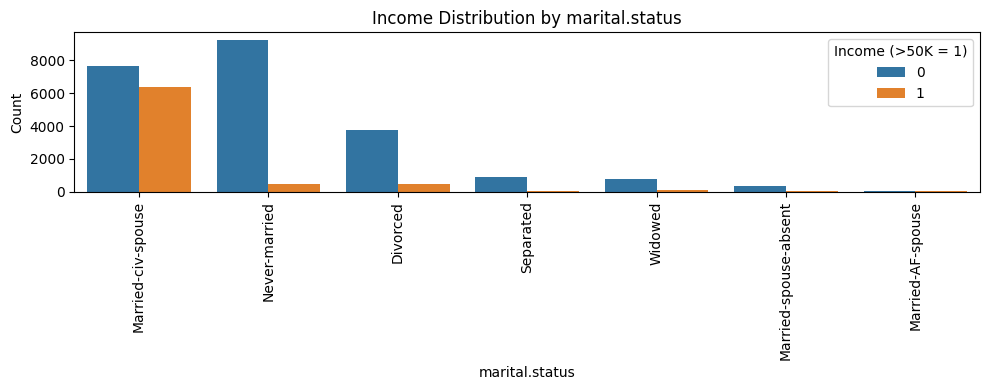

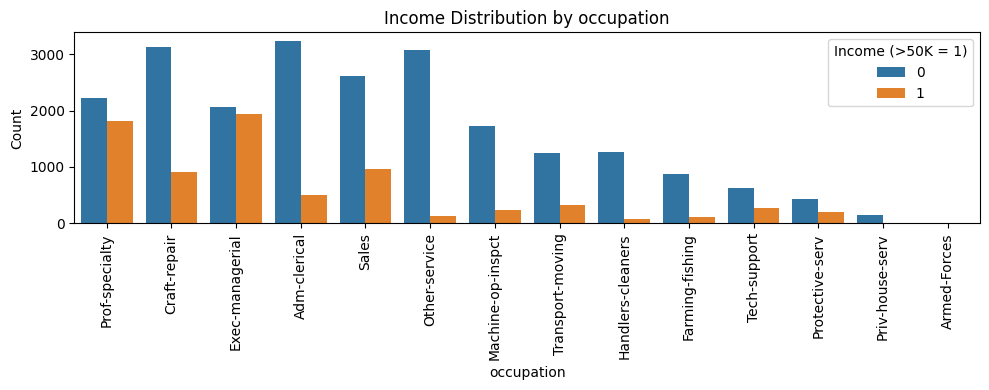

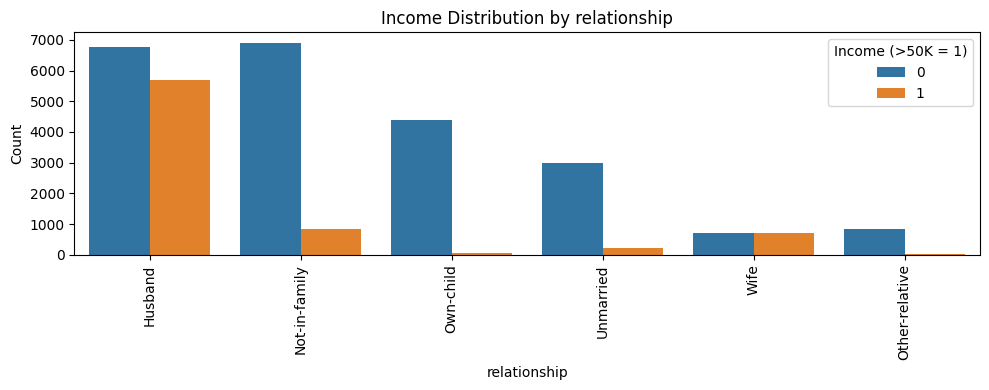

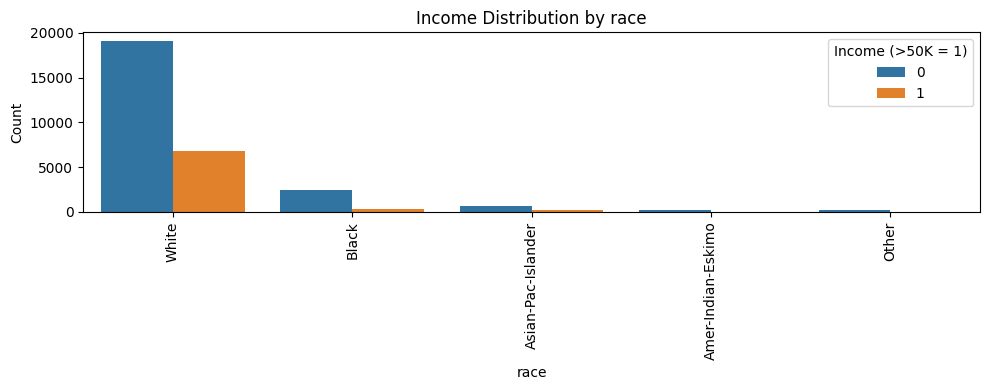

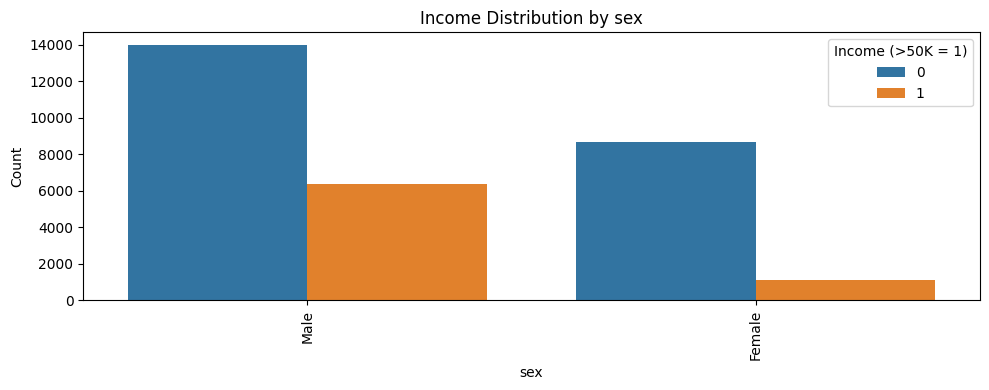

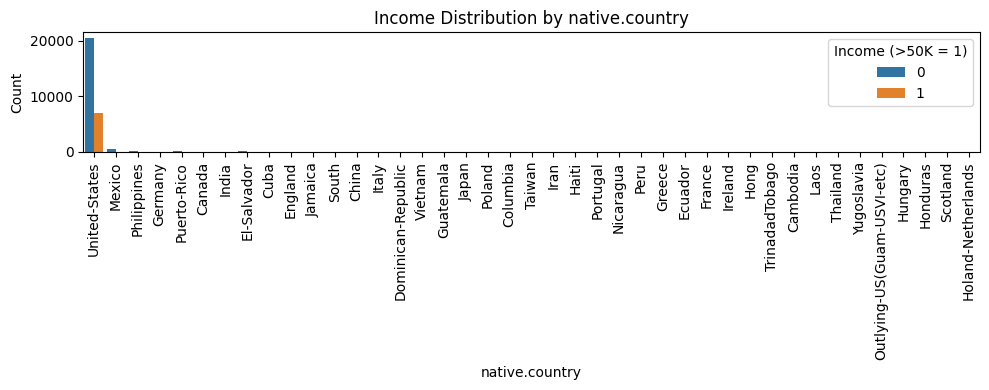

In [82]:
# plot categorical columns (imbalance noticed + exponential looking graphs)
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, hue='income_binary', data=df_clean, order=df_clean[col].value_counts().index)
    plt.title(f"Income Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Income (>50K = 1)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [83]:
df_categ = df_categ.drop(columns=['income'])  # column dropped (more like an extra step, could've replaced)

In [84]:
df_categ  # check

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_TrinadadTobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,132870,9,0,4356,18,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [85]:
# change the column names
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)

In [86]:
df_categ  # check

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_binary,workclass_Local_gov,workclass_Private,workclass_Self_emp_inc,...,native_country_Portugal,native_country_Puerto_Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_TrinadadTobago,native_country_United_States,native_country_Vietnam,native_country_Yugoslavia
1,82,132870,9,0,4356,18,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [87]:
df_categ_final = df_categ.astype(float)  # fix data error by making datatype consistent

- When acquiring the summary statistic of the numeric variables, it can be seen that some variables (capital.gain, capital.loss, hours.per.week), assuming normally distributed, contains potential outliers
- Correlation matrix shows that there are no other highly correlated predictors
- There are categorical variables with class imbalances:
    - Workclass has an imbalance on "private"
    - Race has an imbalance on "white"
    - Native Country has a big imbalance on "United-States"
    - There is an imbalance with the income as more people have an income of less than or equal to 50k
- 2399 rows (around 7% of the data) were removed for the "convenience" of the model to be made since it is not ideal for LPM models to deal with NaN values (around 7% of a dataset of 34k+)
- Noticed data loss on some variables upon dropping the rows, example is "Never-worked" for workclass (this was noticed when checking the basis variable for categorical beta coefficients)

## 2. Train-Test Split and Feature Selection

In [88]:
# Refit same as assessment 2
X = df_categ_final.loc[:, df_categ_final.columns != 'income_binary'].copy()
y = df_categ_final['income_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [89]:
# display shape of each set
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24129, 96)
X_test shape: (6033, 96)
y_train shape: (24129,)
y_test shape: (6033,)


In [90]:
# decision tree classifier
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [91]:
# Generate importance scores of each feature (only showing top 20 the rest still prints if you remove .head(20))
importances = dt.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(20)

,Feature,Importance
28,marital_status_Married_civ_spouse,0.197458
1,fnlwgt,0.187472
0,age,0.121427
2,education_num,0.112387
3,capital_gain,0.104095
5,hours_per_week,0.063198
4,capital_loss,0.034425
7,workclass_Private,0.011049
35,occupation_Exec_managerial,0.010462
43,occupation_Sales,0.009251


C:\Users\Thom\AppData\Local\Temp\ipykernel_21528\3997574624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df_sorted, palette="viridis")


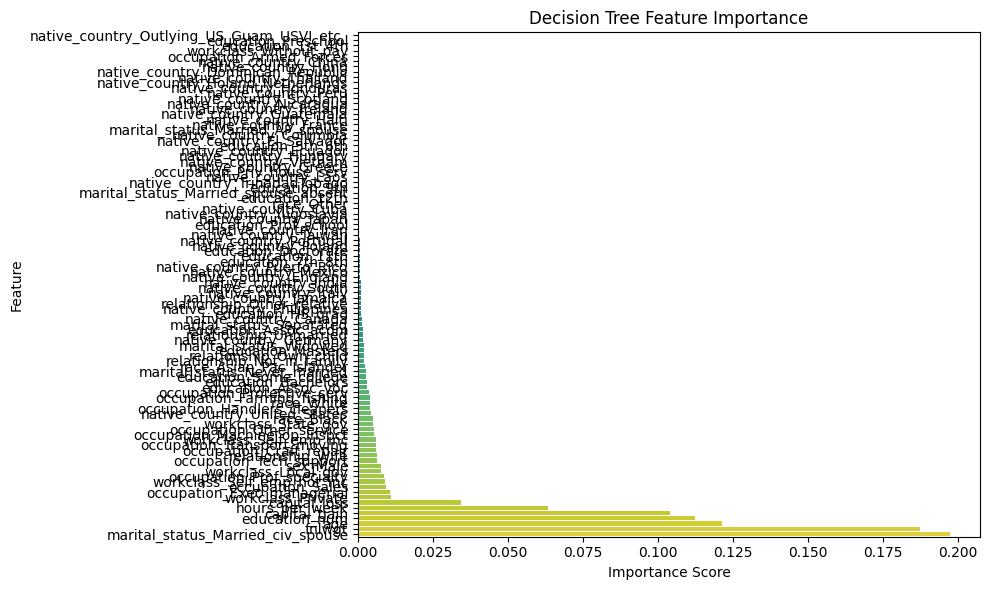

In [92]:
# Sort by importance for plotting
importance_df_sorted = importance_df.sort_values(by="Importance", ascending=True)  # ascending for horizontal bars

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df_sorted, palette="viridis")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- Hard to read with so many features but so far strongest is martial_status_Married_civ_spouse

In [93]:
# display top 12 features in terms of score
top_12_features = importance_df.head(12)["Feature"].tolist()
top_12_features

['marital_status_Married_civ_spouse',
 'fnlwgt',
 'age',
 'education_num',
 'capital_gain',
 'hours_per_week',
 'capital_loss',
 'workclass_Private',
 'occupation_Exec_managerial',
 'occupation_Sales',
 'workclass_Self_emp_not_inc',
 'occupation_Prof_specialty']

C:\Users\Thom\AppData\Local\Temp\ipykernel_21528\3543939897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_features, palette="viridis")


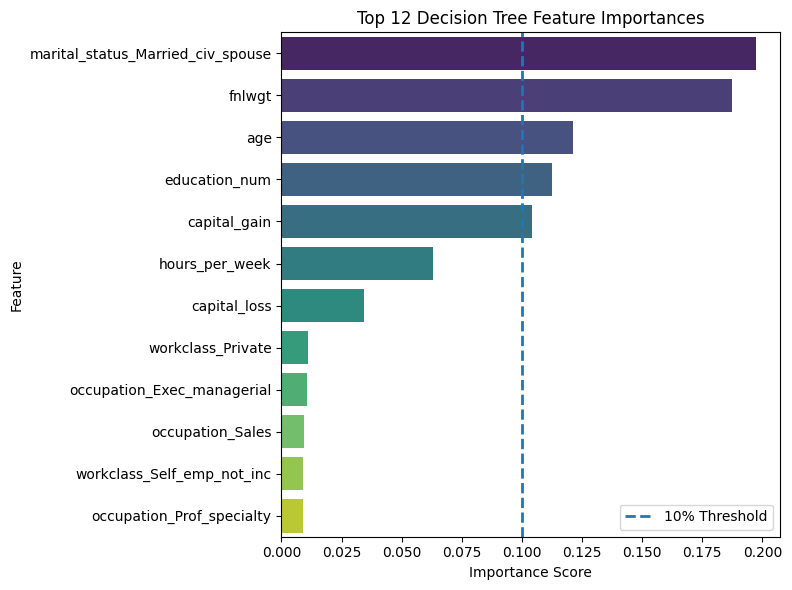

In [94]:
top_features = importance_df.sort_values(by="Importance", ascending=False).head(12)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=top_features, palette="viridis")

# 10% reference line
plt.axvline(x=0.10, linestyle='--', linewidth=2, label='10% Threshold')

plt.title("Top 12 Decision Tree Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

- Shows features with the strongest relative importance in the model (5 features go beyond the set threshold to show its really important and not just there because its highest amongst the group)

In [95]:
# did it get selected (only showing top 20 the rest still prints if you remove .head(20))
importance_df["Selected"] = importance_df["Feature"].apply(
    lambda x: "Yes" if x in top_12_features else "No"
)

feature_selection_table = importance_df.copy()
feature_selection_table.head(20)

,Feature,Importance,Selected
28,marital_status_Married_civ_spouse,0.197458,Yes
1,fnlwgt,0.187472,Yes
0,age,0.121427,Yes
2,education_num,0.112387,Yes
3,capital_gain,0.104095,Yes
5,hours_per_week,0.063198,Yes
4,capital_loss,0.034425,Yes
7,workclass_Private,0.011049,Yes
35,occupation_Exec_managerial,0.010462,Yes
43,occupation_Sales,0.009251,Yes


In [96]:
# only use the top 12 features for train-test
X_train_selected = X_train[top_12_features]
X_test_selected  = X_test[top_12_features]

# Add constant for statsmodels
X_train_sm = sm.add_constant(X_train_selected)
X_test_sm  = sm.add_constant(X_test_selected)

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)
print("X_train_selected shape:", X_train_sm.shape)
print("X_test_selected shape:", X_test_sm.shape)

X_train_selected shape: (24129, 12)
X_test_selected shape: (6033, 12)
X_train_selected shape: (24129, 13)
X_test_selected shape: (6033, 13)


## 3. Four-Model Training and Comparison

In [97]:
# ================================
# 1) Linear Probability Model (LPM)
# ================================
lpm_sm = sm.OLS(y_train, X_train_sm).fit()
print("\n=== Linear Probability Model (LPM) Summary ===")
print(lpm_sm.summary())

# LPM predictions
y_train_pred_lpm = lpm_sm.predict(X_train_sm)
y_train_pred_lpm_class = (y_train_pred_lpm >= 0.5).astype(int)

# ================================
# 2) Logistic Regression
# ================================
logit_sm = sm.Logit(y_train, X_train_sm).fit(disp=False)
print("\n=== Logistic Regression Summary ===")
print(logit_sm.summary())

# Logistic predictions
y_train_pred_logreg_prob  = logit_sm.predict(X_train_sm)
y_train_pred_logreg_class = (y_train_pred_logreg_prob >= 0.5).astype(int)

# ================================
# 3) K-Nearest Neighbors (K=9)
# ================================
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_selected, y_train)
y_train_pred_knn = knn.predict(X_train_selected)

print("\n=== K-Nearest Neighbors ===")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred_knn):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_knn):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred_knn):.4f}")
print(f"F1-Score : {f1_score(y_train, y_train_pred_knn):.4f}")

# ================================
# 4) Decision Tree
# ================================
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_selected, y_train)
y_train_pred_dt = dt_model.predict(X_train_selected)

# Feature importance
dt_importance_df = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== Decision Tree Feature Importance ===")
print(dt_importance_df)

print("\n=== Decision Tree Performance ===")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred_dt):.4f}")
print(f"F1-Score : {f1_score(y_train, y_train_pred_dt):.4f}")


=== Linear Probability Model (LPM) Summary ===
                            OLS Regression Results                            
Dep. Variable:          income_binary   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     1070.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:40:48   Log-Likelihood:                -8858.9
No. Observations:               24129   AIC:                         1.774e+04
Df Residuals:                   24116   BIC:                         1.785e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

- Predicting training sets to get an understanding of K-NN and DT on their training set
- There's a p-value higher than 0.05 workclass_Private in both LPM and LOGIT
- Weird DT performance (near perfect/perfect)
- Note/Definition: Decision tree helps select features better (tells you what you should use based on predictive power)

In [98]:
# Tree info
print(f"Tree depth        : {dt_model.get_depth()}")
print(f"Number of leaves  : {dt_model.get_n_leaves()}")
print(f"Number of nodes   : {dt_model.tree_.node_count}")

Tree depth        : 41
Number of leaves  : 3968
Number of nodes   : 7935


- The tree is very deep and has many nodes which may lead to the model memorizing data instead of choosing/predicting in the initial summary

In [99]:
# ================================
# Comparative Table: LPM vs Logistic Regression
# ================================

# Extract coefficients (statsmodels)
lpm_coef   = lpm_sm.params
logit_coef = logit_sm.params

# Combine into DataFrame
comparative_df = pd.DataFrame({
    "Feature": lpm_coef.index,   # includes 'const'
    "LPM_Coefficient": np.round(lpm_coef.values, 4),
    "Logistic_Coefficient": np.round(logit_coef.values, 4)
})

# Remove constant for feature-only comparison (optional but cleaner)
comparative_df = comparative_df[comparative_df["Feature"] != "const"]

# Calculate difference
comparative_df["Difference"] = np.round(
    comparative_df["LPM_Coefficient"] - comparative_df["Logistic_Coefficient"], 4
)

# Sort by absolute difference
comparative_df = comparative_df.sort_values(
    by="Difference", key=lambda x: np.abs(x), ascending=False
)

# Display
print("=== Comparative Coefficients Table (LPM vs Logistic Regression) ===\n")
print(comparative_df.reset_index(drop=True))

=== Comparative Coefficients Table (LPM vs Logistic Regression) ===

                              Feature  LPM_Coefficient  Logistic_Coefficient  \
0   marital_status_Married_civ_spouse         0.308500              2.468200   
1          occupation_Exec_managerial         0.147800              0.865500   
2          workclass_Self_emp_not_inc        -0.082800             -0.618500   
3           occupation_Prof_specialty         0.097400              0.539800   
4                    occupation_Sales         0.057700              0.345000   
5                       education_num         0.034800              0.296900   
6                   workclass_Private        -0.009900             -0.057800   
7                      hours_per_week         0.002800              0.030000   
8                                 age         0.002900              0.028600   
9                        capital_loss         0.000100              0.000600   
10                       capital_gain         0.000

- After using feature selection the coefficients of logistic regression is significantly larger than in lpm
- Some features feel weird being here as a top 12 selection like fnlgwt, marital_status_Married_civ_spouse because if I hear these two features it doesn't seem to have any correlation to higher or lower income. The rest feels right
- The signs are consistent positive in both and negative in both LPM and LOGIT

## 4. Decision Tree Visualization

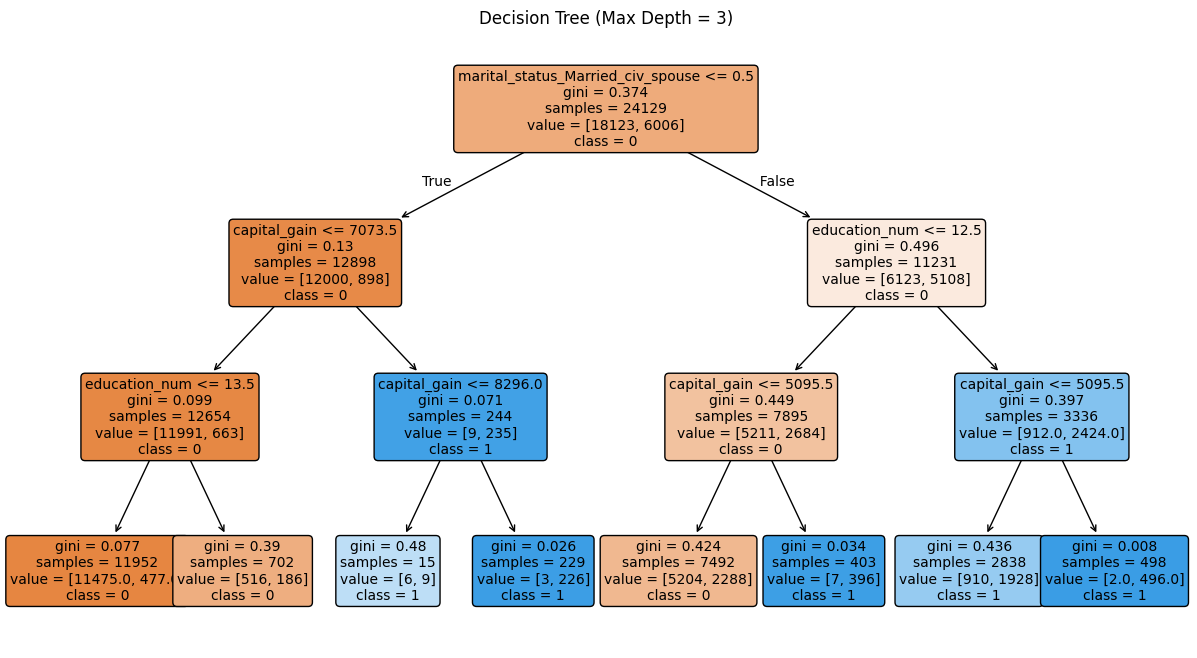

Decision Tree Performance (Max Depth = 3) - Training Set:
  Accuracy : 0.8392
  Precision: 0.767
  Recall   : 0.5087
  F1-Score : 0.6117



In [100]:
# Use feature-selected dataset
X_train = X_train_selected
X_test  = X_test_selected
y_train = y_train
y_test  = y_test
feature_names = X_train.columns

# ================================
# Train Decision Tree (Max Depth = 3 for visualization)
# ================================
viz_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
viz_dt.fit(X_train, y_train)

# ================================
# Plot Decision Tree
# ================================
plt.figure(figsize=(15,8))
plot_tree(
    viz_dt,
    feature_names=feature_names,
    class_names=['0','1'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree (Max Depth = 3)')
plt.show()

# ================================
# Evaluate Tree on Training Set
# ================================
y_train_pred = viz_dt.predict(X_train)
train_acc = round(accuracy_score(y_train, y_train_pred), 4)
train_precision = round(precision_score(y_train, y_train_pred, zero_division=0), 4)
train_recall = round(recall_score(y_train, y_train_pred, zero_division=0), 4)
train_f1 = round(f1_score(y_train, y_train_pred, zero_division=0), 4)

print("Decision Tree Performance (Max Depth = 3) - Training Set:")
print(f"  Accuracy : {train_acc}")
print(f"  Precision: {train_precision}")
print(f"  Recall   : {train_recall}")
print(f"  F1-Score : {train_f1}\n")

- Since DT was limited to depth 3 the performance starts to show something farther from 1 (more realistic than memorized) in both train and test (we do test in later parts no more train)
- root node, the model finds martial_status_Married_civ_spouse to be the strongest in predictive power
- 1st level, if the data is not (0) martial_status_Married_civ_spouse it will go to capital gain <= 7073.5 else (1) education number <= 12.5 (number tresholds must be met to move on)
- 2nd level, if the thresholds has been met move to true else false

## 5. Model Performance Evaluation

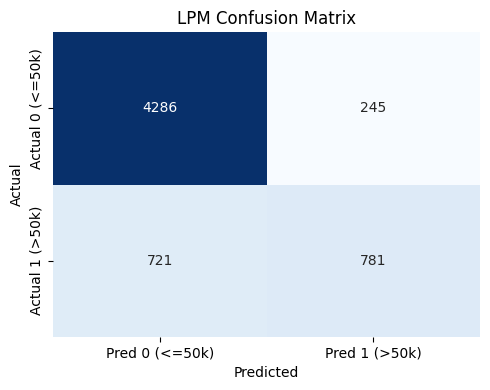


LPM Performance:
  Accuracy   : 0.8399
  Precision  : 0.7612
  Recall     : 0.5200
  F1-Score   : 0.6179
  True Negatives (TN) : 4286
  True Positives (TP) : 781
  Type I Error (FP) : 245 (FPR = 0.0541)
  Type II Error (FN) : 721 (FNR = 0.4800)


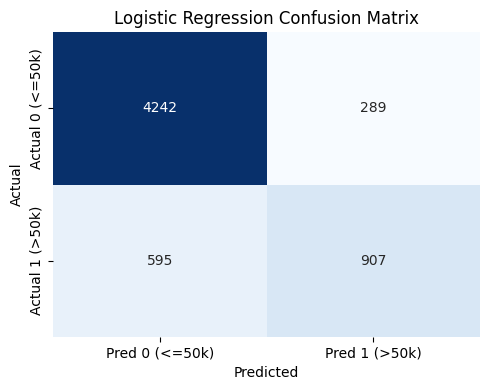


Logistic Regression Performance:
  Accuracy   : 0.8535
  Precision  : 0.7584
  Recall     : 0.6039
  F1-Score   : 0.6723
  True Negatives (TN) : 4242
  True Positives (TP) : 907
  Type I Error (FP) : 289 (FPR = 0.0638)
  Type II Error (FN) : 595 (FNR = 0.3961)


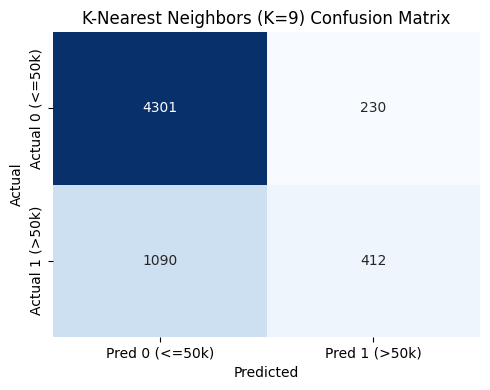


K-Nearest Neighbors (K=9) Performance:
  Accuracy   : 0.7812
  Precision  : 0.6417
  Recall     : 0.2743
  F1-Score   : 0.3843
  True Negatives (TN) : 4301
  True Positives (TP) : 412
  Type I Error (FP) : 230 (FPR = 0.0508)
  Type II Error (FN) : 1090 (FNR = 0.7257)


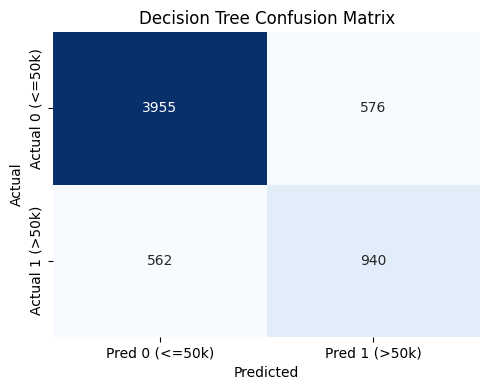


Decision Tree Performance:
  Accuracy   : 0.8114
  Precision  : 0.6201
  Recall     : 0.6258
  F1-Score   : 0.6229
  True Negatives (TN) : 3955
  True Positives (TP) : 940
  Type I Error (FP) : 576 (FPR = 0.1271)
  Type II Error (FN) : 562 (FNR = 0.3742)


In [101]:
# ================================
# TEST SET PREDICTIONS
# ================================

# ---- LPM (statsmodels OLS) ----
y_test_pred_lpm_prob  = lpm_sm.predict(X_test_sm)
y_test_pred_lpm_class = (y_test_pred_lpm_prob >= 0.5).astype(int)

# ---- Logistic Regression (statsmodels) ----
y_test_pred_logreg_prob  = logit_sm.predict(X_test_sm)
y_test_pred_logreg_class = (y_test_pred_logreg_prob >= 0.5).astype(int)

# ---- KNN ----
y_test_pred_knn = knn.predict(X_test_selected)

# ---- Decision Tree ----
y_test_pred_dt = dt_model.predict(X_test_selected)

# ================================
# Function to plot confusion matrix with metrics
# ================================
def plot_cm_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])

    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0 (<=50k)", "Actual 1 (>50k)"],
        columns=["Pred 0 (<=50k)", "Pred 1 (>50k)"]
    )
    
    # Plot heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    # Extract confusion matrix elements
    TN, FP, FN, TP = cm.ravel()
    
    # ---- Error counts ----
    type1_count = FP   # False Positives
    type2_count = FN   # False Negatives
    
    # ---- Error rates ----
    type1_rate = FP / (FP + TN) if (FP + TN) != 0 else 0   # FPR
    type2_rate = FN / (FN + TP) if (FN + TP) != 0 else 0   # FNR
    
    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    
    # Print metrics
    print(f"\n{model_name} Performance:")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"  True Negatives (TN) : {TN}")
    print(f"  True Positives (TP) : {TP}")
    print(f"  Type I Error (FP) : {type1_count} (FPR = {type1_rate:.4f})")
    print(f"  Type II Error (FN) : {type2_count} (FNR = {type2_rate:.4f})")

# ================================
# Plot all models with metrics (TEST SET)
# ================================
models_preds = {
    "LPM": y_test_pred_lpm_class,
    "Logistic Regression": y_test_pred_logreg_class,
    "K-Nearest Neighbors (K=9)": y_test_pred_knn,
    "Decision Tree": y_test_pred_dt
}

for name, y_pred in models_preds.items():
    plot_cm_metrics(y_test, y_pred, name)

- Logistics Regression has the highest Predictive Accuracy of 0.8535 compared to LPM (0.8399), K-NN (0.7812), DT (0.8114)
- Decision Tree has the highest Type I Error rate of 0.1271 compared to LPM (0.0541), LOGIT (0.0638), K-NN (0.0508)
- K-NN has the highest Type II Error rate of  0.7257 compared to LPM (0.4800), LOGIT (0.3961), DT (0.3742)
- Number of error tells how much mistakes the model made
- Rate of error tells out of all the models how severe the errors actually are
- Showing that there is fewer Type I Errors (False Positive/False Alarms) commited compared to the large number of Type II Errors (False Negatives/Misses)

In [102]:
# ================================
# Summary metrics table
# ================================
metrics_list = []

for name, y_pred in models_preds.items():  # use class predictions
    acc = round(accuracy_score(y_test, y_pred), 4)
    precision = round(precision_score(y_test, y_pred, zero_division=0), 4)
    recall = round(recall_score(y_test, y_pred, zero_division=0), 4)
    f1 = round(f1_score(y_test, y_pred, zero_division=0), 4)
    
    metrics_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(metrics_list)

print("=== Model Performance Comparison (Test Set) ===\n")
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))

=== Model Performance Comparison (Test Set) ===

                    Model  Accuracy  Precision  Recall  F1-Score
                      LPM    0.8399     0.7612  0.5200    0.6179
      Logistic Regression    0.8535     0.7584  0.6039    0.6723
K-Nearest Neighbors (K=9)    0.7812     0.6417  0.2743    0.3843
            Decision Tree    0.8114     0.6201  0.6258    0.6229


- The model with the highest accuracy is Logistic Regression (0.8535) meaning it is the most "correct" model
- The model with the best balance of precision and recall is Logistic Regression (0.6723) meaning it has the most harmony between precision and recall
- Comparing machine learning models (K-NN and DT) to traditional methods (LPM and LOGIT), The performance seems to be consistent in all 4 metrics for the traditional methods (like closely similar) whilst mlms seems to be targeting more of a nieche as K-NN is not great but DT is but K-NN still have some uses even with its poor performances in this particular set. For example, quick analysis for small to medium datasets since its the simplest, it can give some quick insight if needed.

## 6. Model Recommendation and Insights

My Recommended Model:
- In terms of overall performance, I would pick Logistics Regression to be my best as it wins in majority of the performance report (Accuracy and F1). General correctness and overall predicitive power is what this model is good at here. Example use case would be for market research and business related strategies.
- In terms of balaned risks, I would pick Decision Tree. Even though its not the highest in F1 we can see that the precision and recall are closely similar to each other compared to other models. This way even without the highest f1 of the group the model shows that it can balance the errors without one dominating the other. Example use case would be social use cases like hiring people based on their "market value"
- The best in my opinion for this case is a model that would minimize the risk of missing cases (Type II Error) especially when applied in the real world like fraud detection.
- So definitively, the best model is Decision Tree as it minimizes misses (Type II Error) whilst also balancing both Type I and II errors.

Model Interpretability:
- In terms of model interpretability, it is how well we can understand the model predictions like its logic and key features.
- In this notebook, K-NN has the hardest interpretability as it is a black-box model (hard to explain the logic of the model) compared to LPM, LOGIT, and DT as LPM and LOGIT are able to show a full summary of their model whilst DT you can create its tree to see its explanations. Though even with the summary provided for LPM and LOGIT it doesn't fully explain how the model arrived with all the numbers at first glance. Unlike DT which has a tree visualization that shows a true-false outcome.
- In ters of feature selection, DT would be hailed as "the best" since with LPM and LOGIT you would manually feature select multiple times while DT is an automated process

Model Performance:
- Model performance is how well the model did when it is tested by measuring its classification metrics (Accuracy, Precision, Recall, F1)
- In terms of performance, LPM, LOGIT, and DT have little issues while K-NN tend to dip.

Difference and Trade-Offs:
- Interpretability is understanding the model's logic and performance is how well does the model do
- High interpretability means harder to understand and higher performance (in the case of this notebook)
- Low interpretability means easier to understand but may have a lower performance compared to high interpretabile models

Deployment in Real World + Key Insights:
- Traditional models (LPM, LOGIT) yield better results so I would say its better overall for a more performance centric use case. Especially when you need to determine the "probability" of your predictor (X) to affect the target (y) (increase/decrease likelihood, odds of happening, etc.)
- Machine Learning Models, seems to be a smaller part of a bigger machine (K-NN and DT) DT being good for selecting the strongest predictors whilst K-NN being a like demo (good with small-medium sets for quick analysis)